In [31]:
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
df1 = pd.read_csv('search-analysis-1773508336746.csv')
print(df1.head)

<bound method NDFrame.head of                                                                                                                                        === РЕЗУЛЬТАТЫ ЯНДЕКС / АЛИСА ===
ID Запрос                          Категория   Область  Есть Алиса Текст Алисы                                        P&G   Конкуренты                      Маркетплейсы
67 elseve                          brand       shampoos true       goldapple.ru\nletu.ru\nmarket.yandex.ru\nLoreal... false true                                    true
68 эльсев шампунь                  brand       shampoos true       \nmarket.yandex.ru\ngoldapple.ru\nrivegauche.ru... false true                                    true
1  памперс                         brand       diapers  true       \nru.wikipedia.org*\nvotonia.ru\nDetmir.ru\npam... true  false                                   true
8  libero подгузники               brand       diapers  true       eapteka.ru\nsigma-med.ru\nmarket.yandex.ru\nvot... false t

In [33]:
df2 = pd.read_csv('search-analysis-1773606579429.csv', nrows=121)
print(df2.head)

<bound method NDFrame.head of                                                                          === ЗАПРОСЫ ===
ID  Запрос                                    Частота Категория Область              Топ
1   памперс                                   850000  brand     diapers             true
2   pampers                                   620000  brand     diapers             true
3   памперс трусики                           320000  brand     diapers             true
4   pampers premium care                      280000  brand     diapers             true
...                                                                                  ...
116 шампунь для окрашенных волос как выбрать  48000   advisory  shampoos            true
117 сухой шампунь как пользоваться            43000   advisory  shampoos            true
118 шампунь от перхоти как часто использовать 38000   advisory  shampoos            true
119 шампунь для жирных волос как выбрать      67000   advisory  shampoos        

In [34]:
print(df1.columns)
print(df2.columns)

Index(['=== РЕЗУЛЬТАТЫ ЯНДЕКС / АЛИСА ==='], dtype='object')
Index(['=== ЗАПРОСЫ ==='], dtype='object')


In [38]:
import pandas as pd
from io import StringIO

queries_path = 'search-analysis-1773606579429.csv'
results_path = 'search-analysis-1773508336746.csv'


def extract_section_from_file(path: str, start_marker: str, end_marker: str | None = None) -> str:
    with open(path, 'r', encoding='utf-8-sig') as file:
        text = file.read()

    start_index = text.find(start_marker)
    if start_index == -1:
        raise ValueError(f'Не найден маркер начала: {start_marker}')

    text = text[start_index + len(start_marker):]

    if end_marker is not None:
        end_index = text.find(end_marker)
        if end_index != -1:
            text = text[:end_index]

    return text.strip()


# 1. Достаём только блок "ЗАПРОСЫ" из первого файла
queries_csv_text = extract_section_from_file(
    path=queries_path,
    start_marker='=== ЗАПРОСЫ ===',
    end_marker='=== РЕЗУЛЬТАТЫ ЯНДЕКС / АЛИСА ==='
)

# 2. Достаём блок "РЕЗУЛЬТАТЫ" из второго файла
results_csv_text = extract_section_from_file(
    path=results_path,
    start_marker='=== РЕЗУЛЬТАТЫ ЯНДЕКС / АЛИСА ==='
)

# 3. Читаем оба блока как нормальные CSV
queries_df = pd.read_csv(StringIO(queries_csv_text))
results_df = pd.read_csv(StringIO(results_csv_text))

# 4. Чистим названия колонок
queries_df.columns = queries_df.columns.str.strip()
results_df.columns = results_df.columns.str.strip()

# 5. Объединяем таблицы
combined_df = pd.merge(
    queries_df,
    results_df,
    on=['ID', 'Запрос', 'Категория', 'Область'],
    how='left'
)

# 6. Приводим порядок колонок
combined_df = combined_df[
    [
        'ID',
        'Запрос',
        'Частота',
        'Категория',
        'Область',
        'Топ',
        'Есть Алиса',
        'Текст Алисы',
        'P&G',
        'Конкуренты',
        'Маркетплейсы'
    ]
]

# 7. Сортируем
combined_df = combined_df.sort_values('ID').reset_index(drop=True)

# 8. Сохраняем
combined_df.to_csv('combined_table.csv', index=False, encoding='utf-8-sig')
combined_df.to_excel('combined_table.xlsx', index=False)

print(combined_df.head(10))
print(combined_df.shape)

   ID                     Запрос  Частота Категория  Область   Топ  \
0   1                    памперс   850000     brand  diapers  True   
1   2                    pampers   620000     brand  diapers  True   
2   3            памперс трусики   320000     brand  diapers  True   
3   4       pampers premium care   280000     brand  diapers  True   
4   5        памперс active baby   250000     brand  diapers  True   
5   6                    huggies   430000     brand  diapers  True   
6   7                     хаггис   210000     brand  diapers  True   
7   8          libero подгузники   130000     brand  diapers  True   
8   9  памперс для новорожденных   190000     brand  diapers  True   
9  10         huggies elite soft   170000     brand  diapers  True   

   Есть Алиса                                        Текст Алисы    P&G  \
0        True  \nru.wikipedia.org*\nvotonia.ru\nDetmir.ru\npa...   True   
1        True  \nru.wikipedia.org*\nvotonia.ru\nDetmir.ru\npa...   True   
2   

In [40]:
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 1. Берём объединённую таблицу
# =========================
# Если combined_df уже есть в памяти, эту строку можно не запускать
# combined_df = pd.read_excel('combined_table.xlsx')

df = combined_df.copy()


# =========================
# 2. Разворачиваем сайты из "Текст Алисы"
# =========================
df['Текст Алисы'] = df['Текст Алисы'].fillna('').astype(str)
df['site'] = df['Текст Алисы'].str.split('\n')

sites_df = df.explode('site').copy()
sites_df['site'] = sites_df['site'].astype(str).str.strip()

# убираем пустые значения
sites_df = sites_df[sites_df['site'] != '']
sites_df = sites_df[sites_df['site'].str.lower() != 'nan']


# =========================
# 3. Нормализация названий сайтов
# =========================
def normalize_site(site: str) -> str:
    site = site.strip().lower()
    site = site.replace('*', '')

    if site.startswith('http://'):
        site = site[len('http://'):]
    if site.startswith('https://'):
        site = site[len('https://'):]

    if site.startswith('www.'):
        site = site[len('www.'):]

    site = site.split('/')[0]
    return site.strip()


sites_df['site'] = sites_df['site'].apply(normalize_site)
sites_df = sites_df[sites_df['site'] != '']


# =========================
# 4. Базовые totals для процентов
# =========================
total_mentions_all = len(sites_df)
total_unique_queries_all = df['Запрос'].nunique()
total_frequency_all = df['Частота'].sum()

total_brand_queries = df[df['Категория'] == 'brand']['Запрос'].nunique()
total_category_queries = df[df['Категория'] == 'category']['Запрос'].nunique()
total_comparative_queries = df[df['Категория'] == 'comparative']['Запрос'].nunique()
total_advisory_queries = df[df['Категория'] == 'advisory']['Запрос'].nunique()

total_diapers_queries = df[df['Область'] == 'diapers']['Запрос'].nunique()
total_shampoos_queries = df[df['Область'] == 'shampoos']['Запрос'].nunique()


# =========================
# 5. Считаем статистику по сайтам
# =========================
site_stats = sites_df.groupby('site').agg(
    total_mentions=('site', 'count'),
    unique_queries=('Запрос', 'nunique'),
    total_frequency=('Частота', 'sum'),
    avg_frequency=('Частота', 'mean'),

    brand_queries=('Категория', lambda x: (x == 'brand').sum()),
    category_queries=('Категория', lambda x: (x == 'category').sum()),
    comparative_queries=('Категория', lambda x: (x == 'comparative').sum()),
    advisory_queries=('Категория', lambda x: (x == 'advisory').sum()),

    diapers_queries=('Область', lambda x: (x == 'diapers').sum()),
    shampoos_queries=('Область', lambda x: (x == 'shampoos').sum()),

    pg_mentions=('P&G', lambda x: x.fillna(False).astype(bool).sum()),
    competitor_mentions=('Конкуренты', lambda x: x.fillna(False).astype(bool).sum()),
    marketplace_mentions=('Маркетплейсы', lambda x: x.fillna(False).astype(bool).sum())
).reset_index()


# =========================
# 6. Добавляем проценты
# =========================
site_stats['mentions_pct'] = (site_stats['total_mentions'] / total_mentions_all * 100).round(2)
site_stats['queries_pct'] = (site_stats['unique_queries'] / total_unique_queries_all * 100).round(2)
site_stats['frequency_pct'] = (site_stats['total_frequency'] / total_frequency_all * 100).round(2)

site_stats['brand_queries_pct'] = (
    site_stats['brand_queries'] / total_brand_queries * 100
).round(2) if total_brand_queries > 0 else 0

site_stats['category_queries_pct'] = (
    site_stats['category_queries'] / total_category_queries * 100
).round(2) if total_category_queries > 0 else 0

site_stats['comparative_queries_pct'] = (
    site_stats['comparative_queries'] / total_comparative_queries * 100
).round(2) if total_comparative_queries > 0 else 0

site_stats['advisory_queries_pct'] = (
    site_stats['advisory_queries'] / total_advisory_queries * 100
).round(2) if total_advisory_queries > 0 else 0

site_stats['diapers_queries_pct'] = (
    site_stats['diapers_queries'] / total_diapers_queries * 100
).round(2) if total_diapers_queries > 0 else 0

site_stats['shampoos_queries_pct'] = (
    site_stats['shampoos_queries'] / total_shampoos_queries * 100
).round(2) if total_shampoos_queries > 0 else 0


# =========================
# 7. Округление и сортировка
# =========================
site_stats['avg_frequency'] = site_stats['avg_frequency'].round(2)

site_stats = site_stats.sort_values(
    by=['frequency_pct', 'queries_pct', 'mentions_pct'],
    ascending=False
).reset_index(drop=True)


# =========================
# 8. Более понятные названия колонок
# =========================
site_stats = site_stats.rename(columns={
    'site': 'Сайт',
    'total_mentions': 'Упоминания',
    'unique_queries': 'Уникальные запросы',
    'total_frequency': 'Суммарная частота',
    'avg_frequency': 'Средняя частота',

    'mentions_pct': '% от всех упоминаний',
    'queries_pct': '% от всех запросов',
    'frequency_pct': '% от всей частоты',

    'brand_queries': 'Brand запросы',
    'category_queries': 'Category запросы',
    'comparative_queries': 'Comparative запросы',
    'advisory_queries': 'Advisory запросы',

    'brand_queries_pct': '% brand запросов',
    'category_queries_pct': '% category запросов',
    'comparative_queries_pct': '% comparative запросов',
    'advisory_queries_pct': '% advisory запросов',

    'diapers_queries': 'Diapers запросы',
    'shampoos_queries': 'Shampoos запросы',

    'diapers_queries_pct': '% diapers запросов',
    'shampoos_queries_pct': '% shampoos запросов',

    'pg_mentions': 'Упоминания в P&G запросах',
    'competitor_mentions': 'Упоминания в конкурентных запросах',
    'marketplace_mentions': 'Упоминания в marketplace запросах'
})


# =========================
# 9. Сохранение
# =========================
site_stats.to_csv('site_statistics_with_percent.csv', index=False, encoding='utf-8-sig')
site_stats.to_excel('site_statistics_with_percent.xlsx', index=False)

print(site_stats.head(20))

                Сайт  Упоминания  Уникальные запросы  Суммарная частота  \
0   market.yandex.ru          58                  57           15805000   
1            ozon.ru          53                  49           12341000   
2          detmir.ru          30                  26            6131000   
3     wildberries.ru          22                  21            5940000   
4       lady.mail.ru          20                  18            5444000   
5       goldapple.ru          20                  20            4979000   
6   ru.wikipedia.org           9                   8            4740000   
7          apteka.ru          22                  21            4045000   
8        randewoo.ru           9                   8            3478000   
9         votonia.ru          12                  12            3392000   
10             kp.ru          22                  21            2591000   
11      stolichki.ru          18                  18            2297000   
12         lenta.com     

Гипотеза 1. Недостаток экспертной поддержки брендов P&G в генеративной выдаче.

Предполагается, что бренды P&G реже попадают в генеративные ответы, потому что контент о них слабее поддержан экспертными и редакционными источниками. Под экспертной поддержкой понимаются медицинские, профессиональные и редакционные материалы: мнения врачей и специалистов, обзоры, статьи, исследования и другие авторитетные публикации. Для проверки гипотезы сравнивается структура источников в ответах по трем группам: ответы, где присутствует P&G; ответы, где присутствуют только конкуренты; ответы, где бренды не представлены. Затем оценивается, связана ли видимость P&G с долей expert/editorial-источников.

=== GROUP SUMMARY ===
       brand_group  queries  avg_total_sources  avg_unique_sources  \
0  competitor_only       38               7.97                7.42   
1        no_brands       41               8.59                8.07   
2  p_and_g_present       41               7.46                6.93   

   avg_marketplace_share_pct  avg_expert_share_pct  avg_editorial_share_pct  \
0                      35.27                  5.07                     5.55   
1                      32.27                  4.73                     4.19   
2                      44.61                  4.24                     8.23   

   avg_expert_editorial_share_pct  avg_other_share_pct  \
0                           10.62                54.10   
1                            8.93                58.80   
2                           12.47                42.93   

   median_expert_editorial_share_pct  weighted_frequency  
0                              10.56             6026000  
1                            

/var/folders/gx/lcw1qljx5pd86gphfq_pqzbc0000gn/T/ipykernel_6936/2670081060.py:183: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


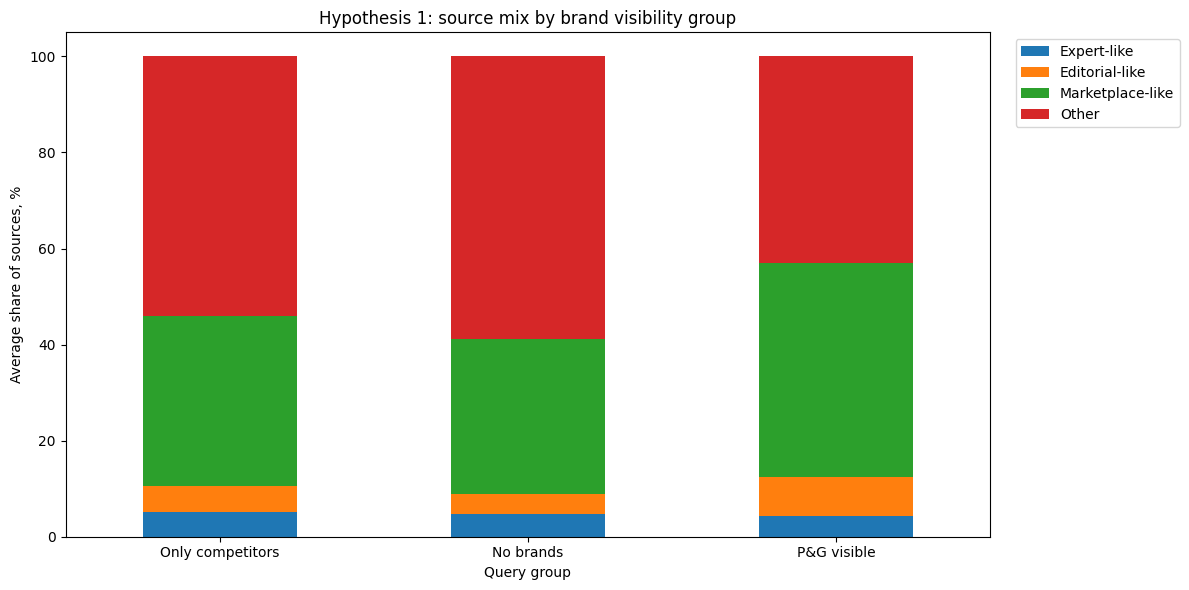

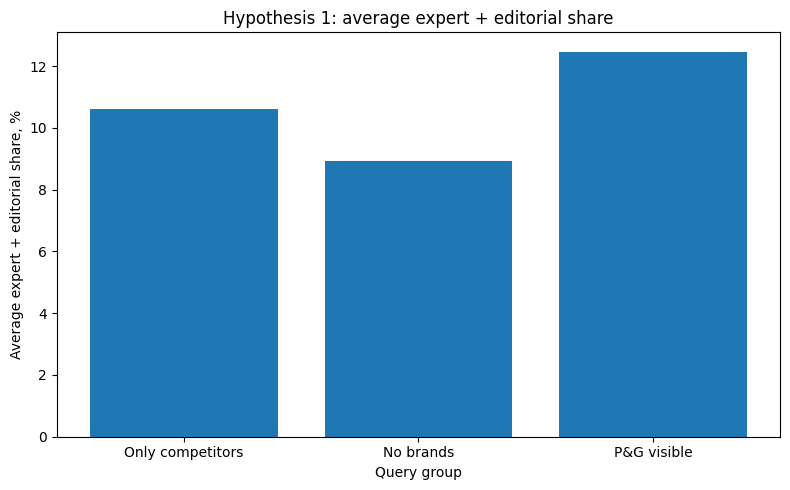

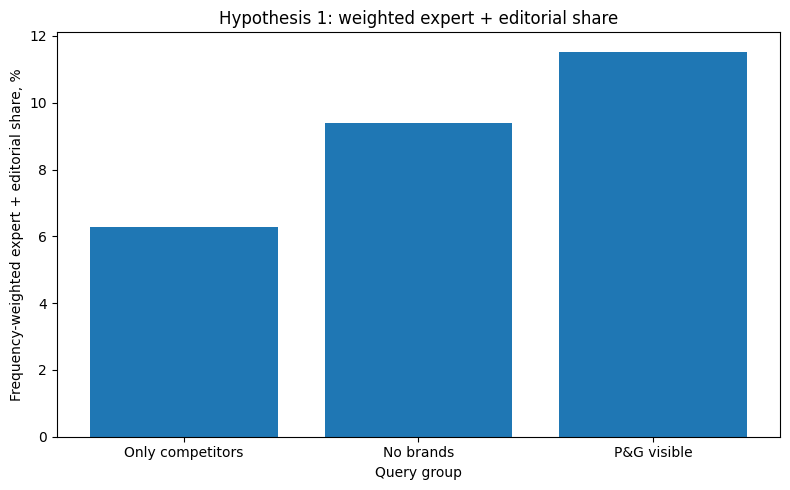

/var/folders/gx/lcw1qljx5pd86gphfq_pqzbc0000gn/T/ipykernel_6936/2670081060.py:265: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


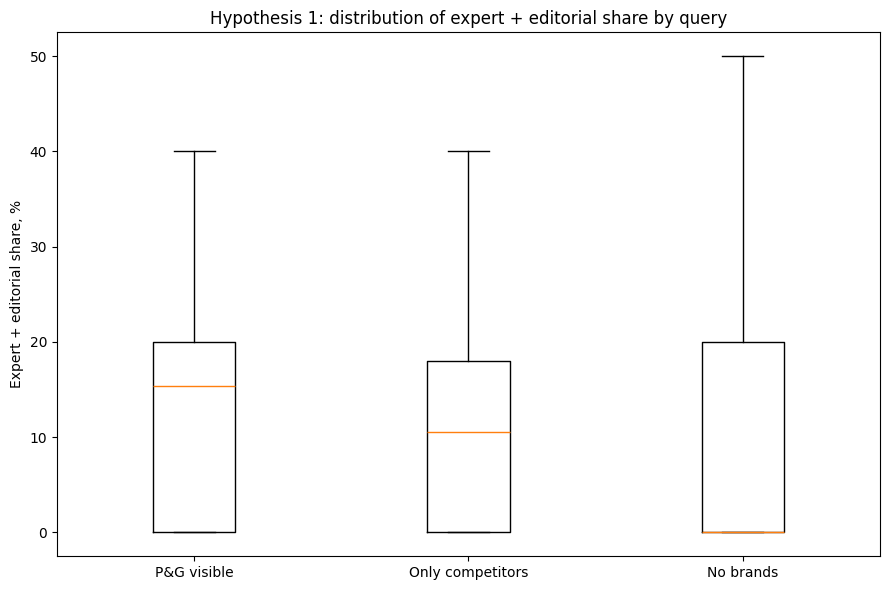

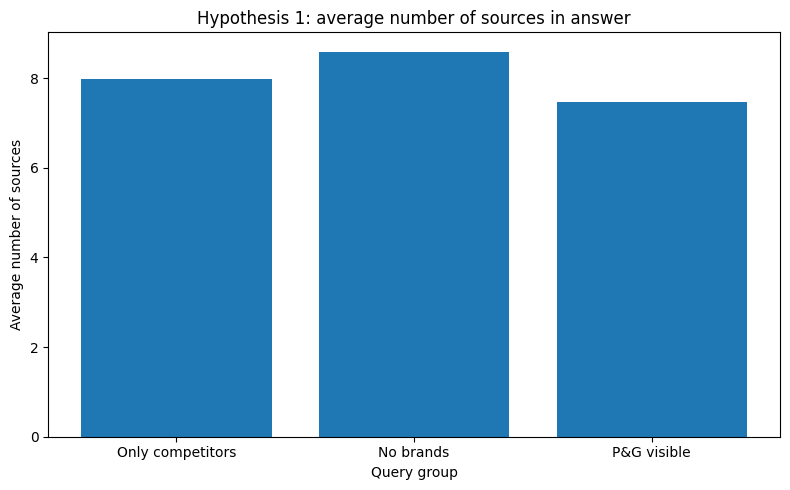

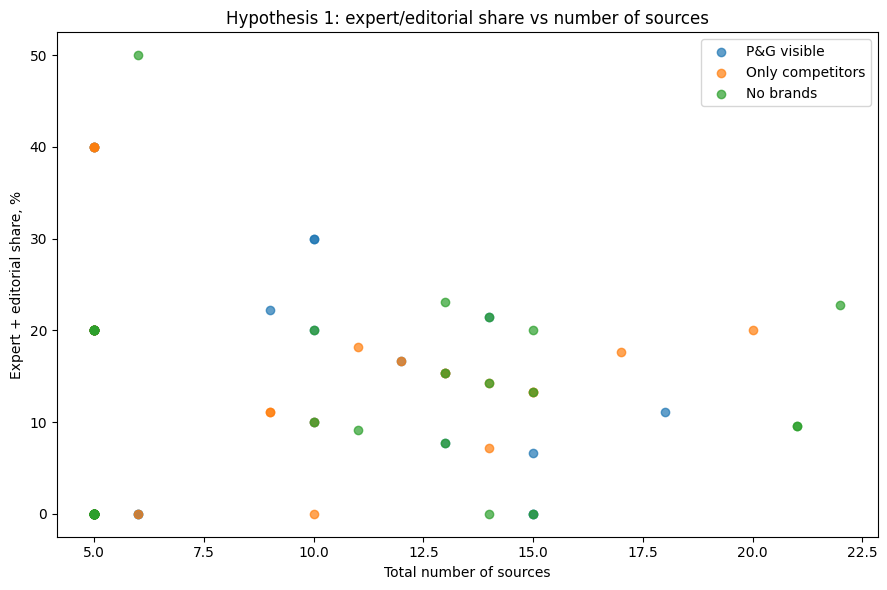

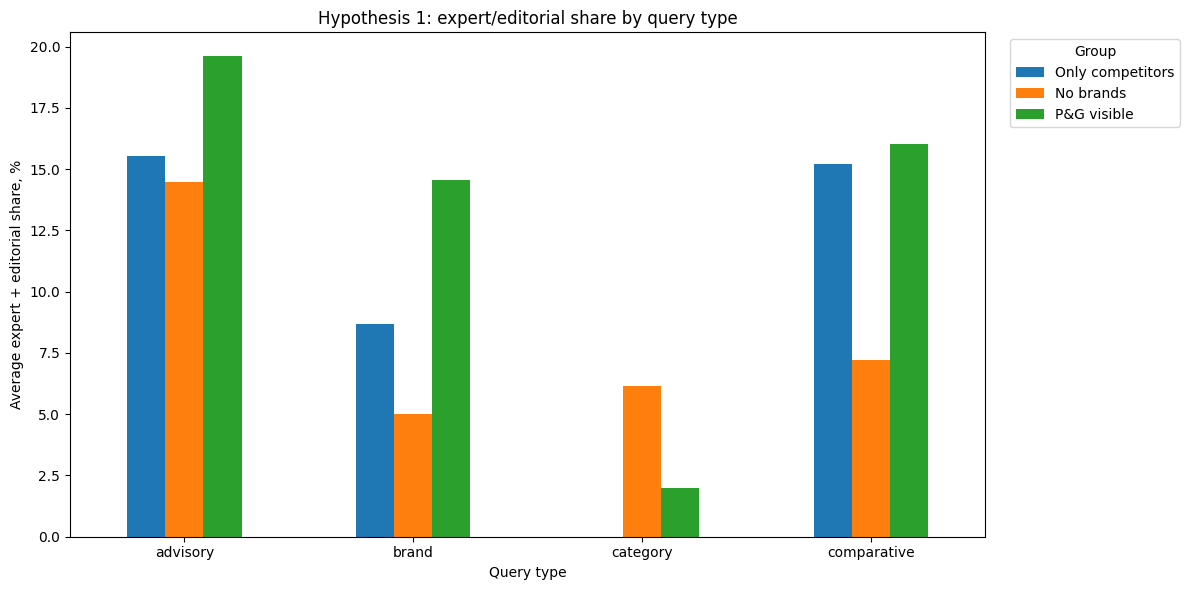


# Гипотеза 1. Недостаток экспертной поддержки брендов P&G в генеративной выдаче

## Что проверяли
Проверялась связь между присутствием P&G в генеративном ответе и долей условного expert/editorial-слоя среди источников ответа.

## Как проверяли
Источники из поля `Текст Алисы` были автоматически разложены на отдельные домены.  
Далее без ручной разметки были построены прокси-классы источников:
- **expert-like** — домены с медицинскими / профессиональными маркерами,
- **editorial-like** — домены с редакционными / медийными маркерами,
- **marketplace-like** — домены маркетплейсов и retail-площадок,
- **other** — остальные источники.

Запросы были разделены на 3 группы:
- **P&G visible**
- **Only competitors**
- **No brands**

## Ключевые результаты
- Средняя доля **expert + editorial** источников:
  - **P&G visible:** 12.47%
  - **Only competitors:** 10.62%
  - **No brands:** 8.93%

- Взвешенная по частоте доля **expert + editorial**:
  - **P&G visible:** 11.53%
  - **Only competitors:** 

In [41]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 0. Папка для графиков
# =========================================
os.makedirs('graphs/h1', exist_ok=True)

def save_plot(filename: str):
    plt.tight_layout()
    plt.savefig(f'graphs/h1/{filename}', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# =========================================
# 1. Подготовка данных
# =========================================
df = combined_df.copy()

# Приводим булевы столбцы к bool
for col in ['P&G', 'Конкуренты', 'Маркетплейсы', 'Есть Алиса', 'Топ']:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(bool)

df['Текст Алисы'] = df['Текст Алисы'].fillna('').astype(str)

def define_brand_group(row):
    if row['P&G']:
        return 'p_and_g_present'
    elif row['Конкуренты']:
        return 'competitor_only'
    else:
        return 'no_brands'

df['brand_group'] = df.apply(define_brand_group, axis=1)

# =========================================
# 2. Вытаскиваем сайты из "Текст Алисы"
# =========================================
def normalize_site(site: str) -> str:
    site = str(site).strip().lower()
    site = site.replace('*', '')
    site = site.replace('\xa0', ' ')
    if site.startswith('http://'):
        site = site[len('http://'):]
    if site.startswith('https://'):
        site = site[len('https://'):]
    if site.startswith('www.'):
        site = site[len('www.'):]
    site = site.split('/')[0]
    return site.strip()

df['site_list'] = df['Текст Алисы'].str.split('\n')

sites_df = df.explode('site_list').copy()
sites_df['site'] = sites_df['site_list'].astype(str).str.strip()
sites_df = sites_df[sites_df['site'] != '']
sites_df = sites_df[sites_df['site'].str.lower() != 'nan']
sites_df['site'] = sites_df['site'].apply(normalize_site)
sites_df = sites_df[sites_df['site'] != '']

# =========================================
# 3. Прокси-классификация источников по домену
#    Без ручной разметки: только по ключевым словам
# =========================================
expert_patterns = [
    'med', 'doc', 'doctor', 'clinic', 'clinica', 'hospital',
    'stomat', 'dent', 'trich', 'pedia', 'pediatr', 'apteka',
    'pharm', 'vrach', 'zdorov', 'health'
]

editorial_patterns = [
    'journal', 'blog', 'mag', 'media', 'news', 'article',
    'parents', 'deti', 'woman', 'wday', 'lisa', 'beauty',
    'editor', 'review'
]

marketplace_patterns = [
    'ozon', 'wildberries', 'market.yandex', 'detmir', 'votonia',
    'goldapple', 'letu', 'rivegauche', 'akusherstvo', 'eapteka',
    'megamarket', 'apteka'
]

def match_any_pattern(text: str, patterns: list[str]) -> bool:
    text = str(text).lower()
    return any(p in text for p in patterns)

sites_df['expert_like'] = sites_df['site'].apply(lambda x: match_any_pattern(x, expert_patterns))
sites_df['editorial_like'] = sites_df['site'].apply(lambda x: match_any_pattern(x, editorial_patterns))
sites_df['marketplace_like'] = sites_df['site'].apply(lambda x: match_any_pattern(x, marketplace_patterns))

# Чтобы один и тот же сайт не считался одновременно marketplace и expert/editorial в итоговых долях
sites_df['expert_like_clean'] = sites_df['expert_like'] & (~sites_df['marketplace_like'])
sites_df['editorial_like_clean'] = sites_df['editorial_like'] & (~sites_df['marketplace_like']) & (~sites_df['expert_like_clean'])
sites_df['expert_editorial_like'] = sites_df['expert_like_clean'] | sites_df['editorial_like_clean']

# =========================================
# 4. Метрики на уровне запроса
# =========================================
query_stats = (
    sites_df.groupby(['ID', 'Запрос', 'Категория', 'Область', 'Частота', 'brand_group'])
    .agg(
        total_sources=('site', 'count'),
        unique_sources=('site', 'nunique'),
        marketplace_sources=('marketplace_like', 'sum'),
        expert_sources=('expert_like_clean', 'sum'),
        editorial_sources=('editorial_like_clean', 'sum'),
        expert_editorial_sources=('expert_editorial_like', 'sum')
    )
    .reset_index()
)

query_stats['other_sources'] = (
    query_stats['total_sources']
    - query_stats['marketplace_sources']
    - query_stats['expert_sources']
    - query_stats['editorial_sources']
)

query_stats['marketplace_share_pct'] = np.where(
    query_stats['total_sources'] > 0,
    query_stats['marketplace_sources'] / query_stats['total_sources'] * 100,
    0
)

query_stats['expert_share_pct'] = np.where(
    query_stats['total_sources'] > 0,
    query_stats['expert_sources'] / query_stats['total_sources'] * 100,
    0
)

query_stats['editorial_share_pct'] = np.where(
    query_stats['total_sources'] > 0,
    query_stats['editorial_sources'] / query_stats['total_sources'] * 100,
    0
)

query_stats['expert_editorial_share_pct'] = np.where(
    query_stats['total_sources'] > 0,
    query_stats['expert_editorial_sources'] / query_stats['total_sources'] * 100,
    0
)

query_stats['other_share_pct'] = np.where(
    query_stats['total_sources'] > 0,
    query_stats['other_sources'] / query_stats['total_sources'] * 100,
    0
)

# =========================================
# 5. Сводка по группам
# =========================================
group_summary = (
    query_stats.groupby('brand_group')
    .agg(
        queries=('ID', 'count'),
        avg_total_sources=('total_sources', 'mean'),
        avg_unique_sources=('unique_sources', 'mean'),
        avg_marketplace_share_pct=('marketplace_share_pct', 'mean'),
        avg_expert_share_pct=('expert_share_pct', 'mean'),
        avg_editorial_share_pct=('editorial_share_pct', 'mean'),
        avg_expert_editorial_share_pct=('expert_editorial_share_pct', 'mean'),
        avg_other_share_pct=('other_share_pct', 'mean'),
        median_expert_editorial_share_pct=('expert_editorial_share_pct', 'median'),
        weighted_frequency=('Частота', 'sum')
    )
    .round(2)
    .reset_index()
)

print('=== GROUP SUMMARY ===')
print(group_summary)

# =========================================
# 6. Частотная взвешенная версия
#    Чтобы учитывать не только число запросов, но и их важность
# =========================================
weighted_summary = (
    query_stats.groupby('brand_group')
    .apply(lambda g: pd.Series({
        'weighted_marketplace_share_pct': np.average(g['marketplace_share_pct'], weights=g['Частота']),
        'weighted_expert_share_pct': np.average(g['expert_share_pct'], weights=g['Частота']),
        'weighted_editorial_share_pct': np.average(g['editorial_share_pct'], weights=g['Частота']),
        'weighted_expert_editorial_share_pct': np.average(g['expert_editorial_share_pct'], weights=g['Частота']),
        'weighted_other_share_pct': np.average(g['other_share_pct'], weights=g['Частота'])
    }))
    .round(2)
    .reset_index()
)

print('\n=== WEIGHTED SUMMARY ===')
print(weighted_summary)

# =========================================
# 7. Таблица для графиков
# =========================================
plot_df = group_summary.merge(weighted_summary, on='brand_group', how='left')

# Удобные подписи
group_name_map = {
    'p_and_g_present': 'P&G visible',
    'competitor_only': 'Only competitors',
    'no_brands': 'No brands'
}
plot_df['brand_group_label'] = plot_df['brand_group'].map(group_name_map)
query_stats['brand_group_label'] = query_stats['brand_group'].map(group_name_map)

# =========================================
# 8. График 1. Структура источников по группам
# =========================================
stacked_df = plot_df.set_index('brand_group_label')[
    [
        'avg_expert_share_pct',
        'avg_editorial_share_pct',
        'avg_marketplace_share_pct',
        'avg_other_share_pct'
    ]
]

stacked_df.columns = ['Expert-like', 'Editorial-like', 'Marketplace-like', 'Other']

stacked_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Hypothesis 1: source mix by brand visibility group')
plt.xlabel('Query group')
plt.ylabel('Average share of sources, %')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h1_source_mix_by_group.png')

# =========================================
# 9. График 2. Expert + Editorial слой
# =========================================
plt.figure(figsize=(8, 5))
plt.bar(plot_df['brand_group_label'], plot_df['avg_expert_editorial_share_pct'])
plt.title('Hypothesis 1: average expert + editorial share')
plt.xlabel('Query group')
plt.ylabel('Average expert + editorial share, %')
plt.xticks(rotation=0)
save_plot('h1_expert_editorial_share.png')

# =========================================
# 10. График 3. Взвешенный expert + editorial слой
# =========================================
plt.figure(figsize=(8, 5))
plt.bar(plot_df['brand_group_label'], plot_df['weighted_expert_editorial_share_pct'])
plt.title('Hypothesis 1: weighted expert + editorial share')
plt.xlabel('Query group')
plt.ylabel('Frequency-weighted expert + editorial share, %')
plt.xticks(rotation=0)
save_plot('h1_weighted_expert_editorial_share.png')

# =========================================
# 11. График 4. Boxplot по запросам
# =========================================
boxplot_groups = [
    query_stats.loc[query_stats['brand_group'] == 'p_and_g_present', 'expert_editorial_share_pct'],
    query_stats.loc[query_stats['brand_group'] == 'competitor_only', 'expert_editorial_share_pct'],
    query_stats.loc[query_stats['brand_group'] == 'no_brands', 'expert_editorial_share_pct']
]

plt.figure(figsize=(9, 6))
plt.boxplot(
    boxplot_groups,
    labels=['P&G visible', 'Only competitors', 'No brands']
)
plt.title('Hypothesis 1: distribution of expert + editorial share by query')
plt.ylabel('Expert + editorial share, %')
save_plot('h1_expert_editorial_boxplot.png')

# =========================================
# 12. График 5. Среднее число источников
# =========================================
plt.figure(figsize=(8, 5))
plt.bar(plot_df['brand_group_label'], plot_df['avg_total_sources'])
plt.title('Hypothesis 1: average number of sources in answer')
plt.xlabel('Query group')
plt.ylabel('Average number of sources')
plt.xticks(rotation=0)
save_plot('h1_avg_total_sources.png')

# =========================================
# 13. График 6. Scatter: expert/editorial vs total sources
# =========================================
plt.figure(figsize=(9, 6))

for group in ['p_and_g_present', 'competitor_only', 'no_brands']:
    part = query_stats[query_stats['brand_group'] == group]
    plt.scatter(
        part['total_sources'],
        part['expert_editorial_share_pct'],
        alpha=0.7,
        label=group_name_map[group]
    )

plt.title('Hypothesis 1: expert/editorial share vs number of sources')
plt.xlabel('Total number of sources')
plt.ylabel('Expert + editorial share, %')
plt.legend()
save_plot('h1_scatter_sources_vs_expert_editorial.png')

# =========================================
# 14. График 7. Срез по типам запросов
# =========================================
type_summary = (
    query_stats.groupby(['Категория', 'brand_group'])
    .agg(
        avg_expert_editorial_share_pct=('expert_editorial_share_pct', 'mean'),
        avg_marketplace_share_pct=('marketplace_share_pct', 'mean'),
        queries=('ID', 'count')
    )
    .round(2)
    .reset_index()
)

pivot_type = type_summary.pivot(
    index='Категория',
    columns='brand_group',
    values='avg_expert_editorial_share_pct'
)

pivot_type = pivot_type.rename(columns=group_name_map)

pivot_type.plot(kind='bar', figsize=(12, 6))
plt.title('Hypothesis 1: expert/editorial share by query type')
plt.xlabel('Query type')
plt.ylabel('Average expert + editorial share, %')
plt.xticks(rotation=0)
plt.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h1_expert_editorial_by_query_type.png')

# =========================================
# 15. Итоговые таблицы
# =========================================
group_summary.to_excel('graphs/h1/h1_group_summary.xlsx', index=False)
weighted_summary.to_excel('graphs/h1/h1_weighted_summary.xlsx', index=False)
query_stats.to_excel('graphs/h1/h1_query_level_stats.xlsx', index=False)

# =========================================
# 16. Автоматический вывод в markdown
# =========================================
pg_value = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'avg_expert_editorial_share_pct'].iloc[0])
comp_value = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'avg_expert_editorial_share_pct'].iloc[0])
nobr_value = float(plot_df.loc[plot_df['brand_group'] == 'no_brands', 'avg_expert_editorial_share_pct'].iloc[0])

pg_weighted = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'weighted_expert_editorial_share_pct'].iloc[0])
comp_weighted = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'weighted_expert_editorial_share_pct'].iloc[0])

market_pg = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'avg_marketplace_share_pct'].iloc[0])
market_comp = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'avg_marketplace_share_pct'].iloc[0])

if pg_value < comp_value and pg_weighted < comp_weighted:
    verdict = 'Гипотеза скорее подтверждается'
    explanation = (
        'в группе запросов с P&G доля expert/editorial-слоя ниже, чем в группе с одними конкурентами, '
        'и это сохраняется даже после взвешивания по частоте запросов.'
    )
elif pg_value >= comp_value and pg_weighted >= comp_weighted:
    verdict = 'Гипотеза скорее не подтверждается'
    explanation = (
        'P&G не проигрывает конкурентам по доле expert/editorial-слоя; '
        'значит, причина видимости лежит не только в недостатке экспертной поддержки.'
    )
else:
    verdict = 'Гипотеза подтверждается частично'
    explanation = (
        'разница между P&G и конкурентами есть, но она неустойчива: часть метрик её поддерживает, а часть — нет.'
    )

markdown_report = f"""
# Гипотеза 1. Недостаток экспертной поддержки брендов P&G в генеративной выдаче

## Что проверяли
Проверялась связь между присутствием P&G в генеративном ответе и долей условного expert/editorial-слоя среди источников ответа.

## Как проверяли
Источники из поля `Текст Алисы` были автоматически разложены на отдельные домены.  
Далее без ручной разметки были построены прокси-классы источников:
- **expert-like** — домены с медицинскими / профессиональными маркерами,
- **editorial-like** — домены с редакционными / медийными маркерами,
- **marketplace-like** — домены маркетплейсов и retail-площадок,
- **other** — остальные источники.

Запросы были разделены на 3 группы:
- **P&G visible**
- **Only competitors**
- **No brands**

## Ключевые результаты
- Средняя доля **expert + editorial** источников:
  - **P&G visible:** {pg_value:.2f}%
  - **Only competitors:** {comp_value:.2f}%
  - **No brands:** {nobr_value:.2f}%

- Взвешенная по частоте доля **expert + editorial**:
  - **P&G visible:** {pg_weighted:.2f}%
  - **Only competitors:** {comp_weighted:.2f}%

- Средняя доля marketplace-like источников:
  - **P&G visible:** {market_pg:.2f}%
  - **Only competitors:** {market_comp:.2f}%

## Интерпретация
**{verdict}.** Это означает, что {explanation}

## Ограничение метода
Это **быстрая прокси-проверка**, а не строгая контентная разметка.  
Мы не классифицировали сайты вручную, поэтому expert/editorial определялись только по признакам в домене.  
Значит, вывод стоит трактовать как предварительный: он хорошо подходит для кейса и исследовательской части, но не как финальное доказательство.

## Практический вывод для кейса
Если P&G уступает конкурентам по expert/editorial-слою, то усиливать нужно не только retail-присутствие, но и:
- редакционные обзоры,
- экспертные публикации,
- профессиональные рекомендации,
- материалы на внешних авторитетных площадках.

Если же отставания по expert/editorial нет, то основную причину слабой видимости нужно искать в других факторах:
- типе запросов,
- структуре источников,
- dominance маркетплейсов,
- общей логике генеративного ответа.
"""

print(markdown_report)

Количество category-запросов: 30
brand_group
no_brands          13
p_and_g_present    10
competitor_only     7
Name: count, dtype: int64
                          Запрос              site
15                    подгузники         lenta.com
15                    подгузники  market.yandex.ru
15                    подгузники           ozon.ru
15                    подгузники    wildberries.ru
15                    подгузники         auchan.ru
16  подгузники для новорожденных      deti.mail.ru
16  подгузники для новорожденных           ozon.ru
16  подгузники для новорожденных    wildberries.ru
16  подгузники для новорожденных          uteka.ru
16  подгузники для новорожденных         detmir.ru
17            подгузники трусики         lenta.com
17            подгузники трусики  market.yandex.ru
17            подгузники трусики           ozon.ru
17            подгузники трусики    perekrestok.ru
17            подгузники трусики  online.globus.ru
18           подгузники 1 размер  market.yandex

/var/folders/gx/lcw1qljx5pd86gphfq_pqzbc0000gn/T/ipykernel_6936/1885611409.py:199: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


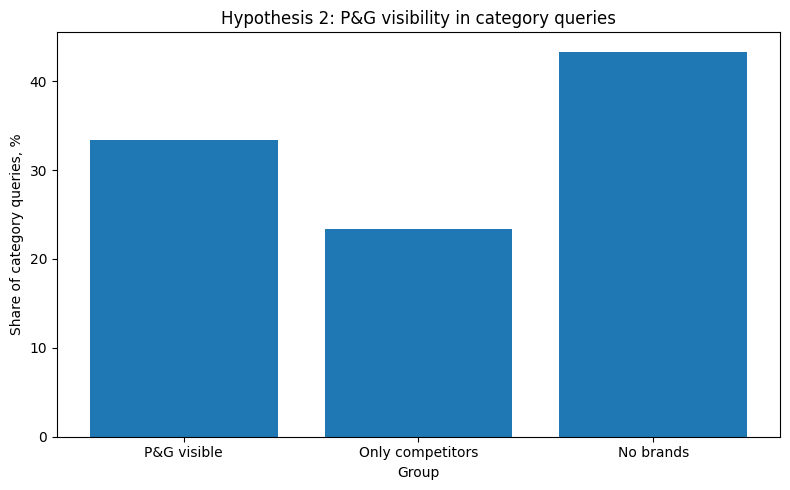

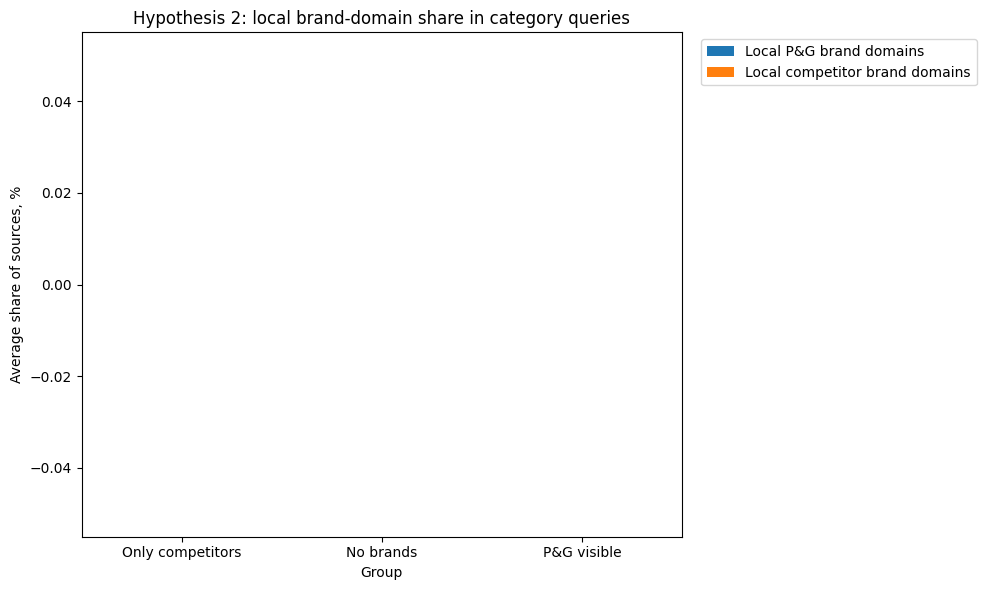

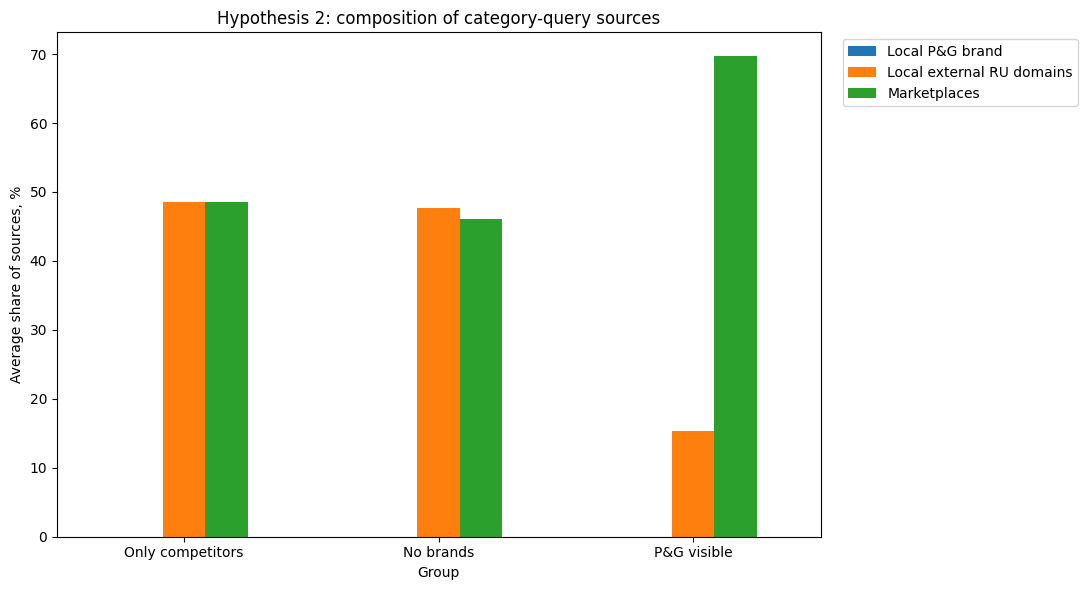

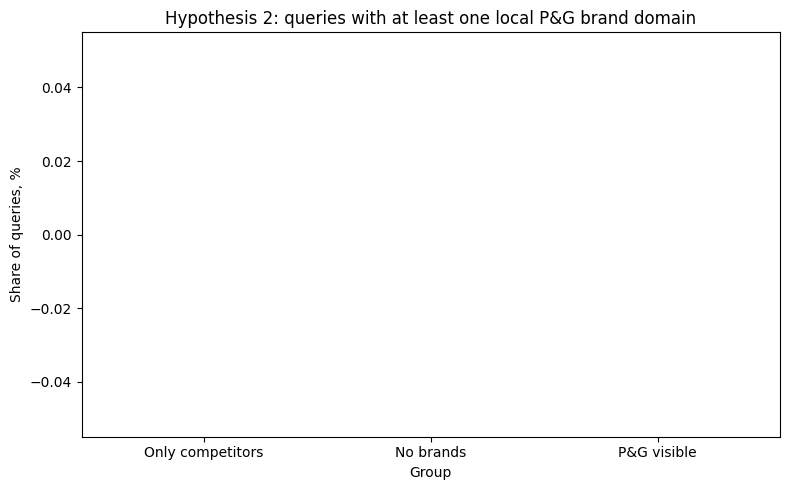

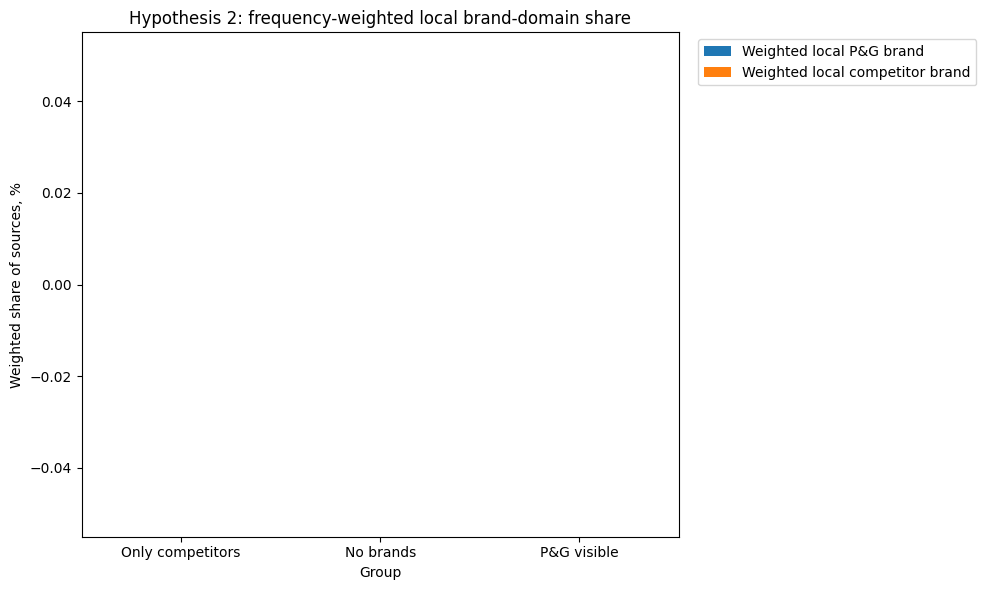

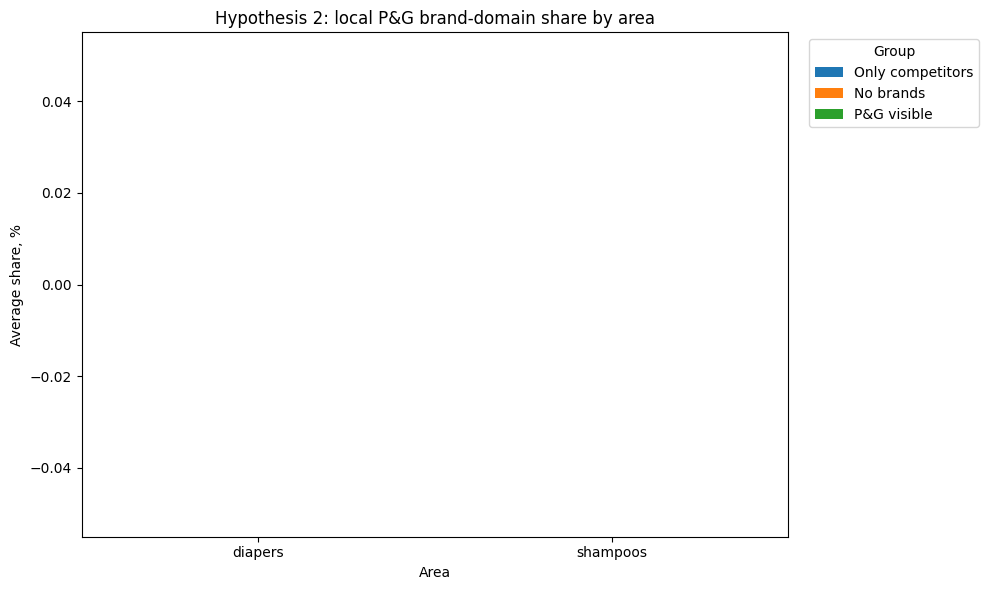

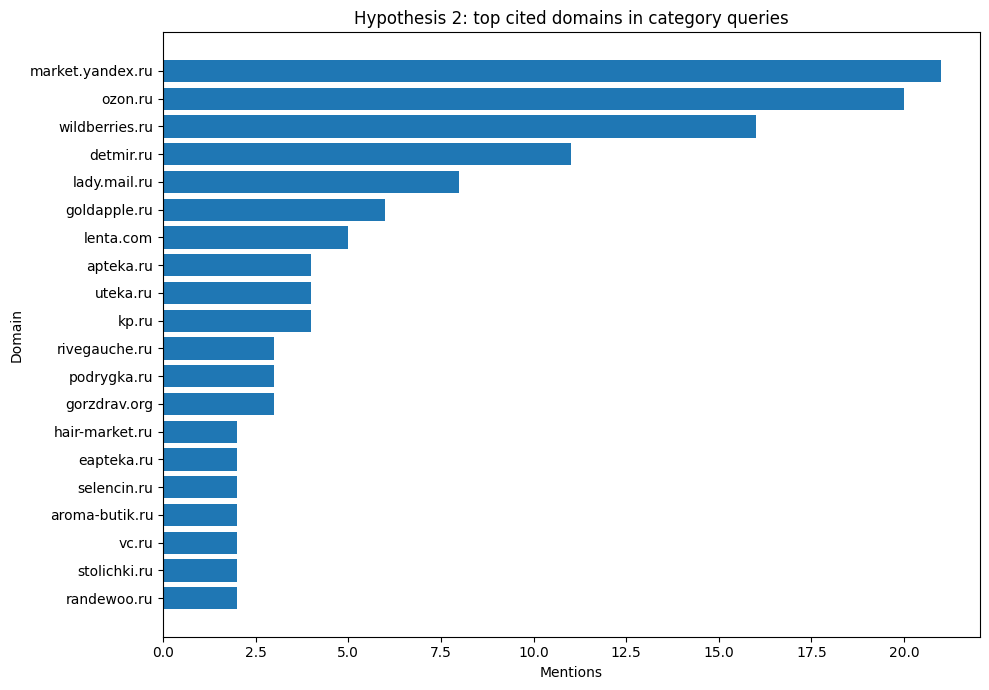


# Гипотеза 2. Проблема локализации и индексации экспертного контента

## Что проверяли
Проверялась идея о том, что низкая видимость P&G в **category-запросах** может быть связана со слабым локальным брендовым присутствием в российской генеративной выдаче.

## Как проверяли
Из общей выборки были взяты только **category-запросы**.  
Далее источники из `Текст Алисы` были разложены на отдельные домены и разделены на несколько простых групп:
- **local P&G brand domains**,
- **local competitor brand domains**,
- **local external RU domains**,
- **marketplaces**.

Здесь мы не проверяем содержимое страниц напрямую, а используем более устойчивую proxy-логику:  
если локальный слой P&G слабый, а ответы в основном собираются из внешних RU-доменов и маркетплейсов, это поддерживает гипотезу о слабой локализации/индексации брендового контента.

## Ключевые результаты
- Доля category-запросов:
  - **P&G visible:** 33.33%
  - **Only competitors:** 23.33%
  - **No brands:** 43.33%

- Средняя доля лока

In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 0. Папка для графиков
# =========================================
os.makedirs('graphs/h2_simple', exist_ok=True)

def save_plot(filename: str):
    plt.tight_layout()
    plt.savefig(f'graphs/h2_simple/{filename}', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# =========================================
# 1. Берём только category-запросы
# =========================================
df = combined_df.copy()

for col in ['P&G', 'Конкуренты', 'Маркетплейсы', 'Есть Алиса', 'Топ']:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(bool)

df['Текст Алисы'] = df['Текст Алисы'].fillna('').astype(str)

category_df = df[df['Категория'].astype(str).str.lower() == 'category'].copy()

def define_brand_group(row):
    if row['P&G']:
        return 'p_and_g_present'
    elif row['Конкуренты']:
        return 'competitor_only'
    else:
        return 'no_brands'

category_df['brand_group'] = category_df.apply(define_brand_group, axis=1)

print('Количество category-запросов:', len(category_df))
print(category_df['brand_group'].value_counts(dropna=False))

# =========================================
# 2. Разворачиваем источники
# =========================================
def normalize_site(site: str) -> str:
    site = str(site).strip().lower()
    site = site.replace('*', '')
    site = site.replace('\xa0', ' ')
    if site.startswith('http://'):
        site = site[len('http://'):]
    if site.startswith('https://'):
        site = site[len('https://'):]
    if site.startswith('www.'):
        site = site[len('www.'):]
    site = site.split('/')[0]
    return site.strip()

category_df['site_list'] = category_df['Текст Алисы'].str.split('\n')

sites_df = category_df.explode('site_list').copy()
sites_df['site'] = sites_df['site_list'].astype(str).str.strip()
sites_df = sites_df[sites_df['site'] != '']
sites_df = sites_df[sites_df['site'].str.lower() != 'nan']
sites_df['site'] = sites_df['site'].apply(normalize_site)
sites_df = sites_df[sites_df['site'] != '']

print(sites_df[['Запрос', 'site']].head(20))

# =========================================
# 3. Простая и устойчивая классификация доменов
# =========================================
pg_brand_keywords = [
    'pampers', 'oralb', 'oral-b', 'blendamed', 'blend-a-med',
    'headandshoulders', 'head-shoulders', 'pantene',
    'herbalessences', 'herbal-essences', 'oldspice', 'old-spice',
    'pg', 'procter'
]

competitor_brand_keywords = [
    'huggies', 'libero', 'elseve', 'loreal', 'clear', 'nivea',
    'syoss', 'schauma', 'johnson', 'johnsons'
]

marketplace_keywords = [
    'ozon', 'wildberries', 'market.yandex', 'detmir', 'votonia',
    'goldapple', 'letu', 'rivegauche', 'eapteka', 'akusherstvo',
    'megamarket'
]

def contains_any(text: str, keywords: list[str]) -> bool:
    text = str(text).lower()
    return any(k in text for k in keywords)

def is_ru_domain(site: str) -> bool:
    site = str(site).lower()
    return site.endswith('.ru') or site.endswith('.рф') or site.endswith('.su')

sites_df['is_ru_domain'] = sites_df['site'].apply(is_ru_domain)
sites_df['is_marketplace'] = sites_df['site'].apply(lambda x: contains_any(x, marketplace_keywords))
sites_df['is_pg_brand_domain'] = sites_df['site'].apply(lambda x: contains_any(x, pg_brand_keywords))
sites_df['is_competitor_brand_domain'] = sites_df['site'].apply(lambda x: contains_any(x, competitor_brand_keywords))

# локальные брендовые домены
sites_df['is_local_pg_brand_domain'] = sites_df['is_ru_domain'] & sites_df['is_pg_brand_domain']
sites_df['is_local_competitor_brand_domain'] = sites_df['is_ru_domain'] & sites_df['is_competitor_brand_domain']

# внешние локальные домены = ru-домен, но не маркетплейс и не брендовый
sites_df['is_local_external_domain'] = (
    sites_df['is_ru_domain']
    & (~sites_df['is_marketplace'])
    & (~sites_df['is_pg_brand_domain'])
    & (~sites_df['is_competitor_brand_domain'])
)

# =========================================
# 4. Метрики на уровне запроса
# =========================================
query_stats = (
    sites_df.groupby(['ID', 'Запрос', 'Область', 'Частота', 'brand_group'])
    .agg(
        total_sources=('site', 'count'),
        unique_sources=('site', 'nunique'),
        ru_sources=('is_ru_domain', 'sum'),
        marketplace_sources=('is_marketplace', 'sum'),
        pg_brand_sources=('is_pg_brand_domain', 'sum'),
        competitor_brand_sources=('is_competitor_brand_domain', 'sum'),
        local_pg_brand_sources=('is_local_pg_brand_domain', 'sum'),
        local_competitor_brand_sources=('is_local_competitor_brand_domain', 'sum'),
        local_external_sources=('is_local_external_domain', 'sum')
    )
    .reset_index()
)

share_cols = [
    'ru_sources',
    'marketplace_sources',
    'pg_brand_sources',
    'competitor_brand_sources',
    'local_pg_brand_sources',
    'local_competitor_brand_sources',
    'local_external_sources'
]

for col in share_cols:
    query_stats[col.replace('_sources', '_share_pct')] = np.where(
        query_stats['total_sources'] > 0,
        query_stats[col] / query_stats['total_sources'] * 100,
        0
    )

query_stats['has_local_pg_brand_source'] = query_stats['local_pg_brand_sources'] > 0
query_stats['has_local_competitor_brand_source'] = query_stats['local_competitor_brand_sources'] > 0

print(query_stats.head())

# =========================================
# 5. Сводка по группам
# =========================================
group_summary = (
    query_stats.groupby('brand_group')
    .agg(
        queries=('ID', 'count'),
        weighted_frequency=('Частота', 'sum'),
        avg_total_sources=('total_sources', 'mean'),
        avg_ru_share_pct=('ru_share_pct', 'mean'),
        avg_marketplace_share_pct=('marketplace_share_pct', 'mean'),
        avg_pg_brand_share_pct=('pg_brand_share_pct', 'mean'),
        avg_competitor_brand_share_pct=('competitor_brand_share_pct', 'mean'),
        avg_local_pg_brand_share_pct=('local_pg_brand_share_pct', 'mean'),
        avg_local_competitor_brand_share_pct=('local_competitor_brand_share_pct', 'mean'),
        avg_local_external_share_pct=('local_external_share_pct', 'mean'),
        share_queries_with_local_pg_brand=('has_local_pg_brand_source', 'mean'),
        share_queries_with_local_competitor_brand=('has_local_competitor_brand_source', 'mean')
    )
    .reset_index()
)

group_summary['share_queries_with_local_pg_brand'] = (
    group_summary['share_queries_with_local_pg_brand'] * 100
).round(2)

group_summary['share_queries_with_local_competitor_brand'] = (
    group_summary['share_queries_with_local_competitor_brand'] * 100
).round(2)

for col in group_summary.columns:
    if col not in ['brand_group', 'queries', 'weighted_frequency']:
        group_summary[col] = group_summary[col].round(2)

print('=== GROUP SUMMARY ===')
print(group_summary)

# =========================================
# 6. Взвешенная по частоте сводка
# =========================================
weighted_summary = (
    query_stats.groupby('brand_group')
    .apply(lambda g: pd.Series({
        'weighted_local_pg_brand_share_pct': np.average(g['local_pg_brand_share_pct'], weights=g['Частота']),
        'weighted_local_competitor_brand_share_pct': np.average(g['local_competitor_brand_share_pct'], weights=g['Частота']),
        'weighted_local_external_share_pct': np.average(g['local_external_share_pct'], weights=g['Частота']),
        'weighted_marketplace_share_pct': np.average(g['marketplace_share_pct'], weights=g['Частота'])
    }))
    .reset_index()
)

for col in weighted_summary.columns:
    if col != 'brand_group':
        weighted_summary[col] = weighted_summary[col].round(2)

print('\n=== WEIGHTED SUMMARY ===')
print(weighted_summary)

plot_df = group_summary.merge(weighted_summary, on='brand_group', how='left')

group_name_map = {
    'p_and_g_present': 'P&G visible',
    'competitor_only': 'Only competitors',
    'no_brands': 'No brands'
}
plot_df['brand_group_label'] = plot_df['brand_group'].map(group_name_map)

# =========================================
# 7. График 1. Видимость P&G в category-запросах
# =========================================
visibility_counts = category_df['brand_group'].value_counts().reindex(
    ['p_and_g_present', 'competitor_only', 'no_brands'],
    fill_value=0
)

visibility_pct = (visibility_counts / visibility_counts.sum() * 100).round(2)

plt.figure(figsize=(8, 5))
plt.bar(['P&G visible', 'Only competitors', 'No brands'], visibility_pct.values)
plt.title('Hypothesis 2: P&G visibility in category queries')
plt.xlabel('Group')
plt.ylabel('Share of category queries, %')
plt.xticks(rotation=0)
save_plot('h2_visibility_share.png')

# =========================================
# 8. График 2. Локальные брендовые домены: P&G vs конкуренты
# =========================================
compare_brand_df = plot_df.set_index('brand_group_label')[
    ['avg_local_pg_brand_share_pct', 'avg_local_competitor_brand_share_pct']
]
compare_brand_df.columns = ['Local P&G brand domains', 'Local competitor brand domains']

compare_brand_df.plot(kind='bar', figsize=(10, 6))
plt.title('Hypothesis 2: local brand-domain share in category queries')
plt.xlabel('Group')
plt.ylabel('Average share of sources, %')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h2_local_brand_domains_compare.png')

# =========================================
# 9. График 3. Локальные внешние домены vs локальные P&G домены
# =========================================
local_mix_df = plot_df.set_index('brand_group_label')[
    ['avg_local_pg_brand_share_pct', 'avg_local_external_share_pct', 'avg_marketplace_share_pct']
]
local_mix_df.columns = ['Local P&G brand', 'Local external RU domains', 'Marketplaces']

local_mix_df.plot(kind='bar', figsize=(11, 6))
plt.title('Hypothesis 2: composition of category-query sources')
plt.xlabel('Group')
plt.ylabel('Average share of sources, %')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h2_source_composition_category_queries.png')

# =========================================
# 10. График 4. Доля запросов, где есть хотя бы один локальный P&G домен
# =========================================
plt.figure(figsize=(8, 5))
plt.bar(
    plot_df['brand_group_label'],
    plot_df['share_queries_with_local_pg_brand']
)
plt.title('Hypothesis 2: queries with at least one local P&G brand domain')
plt.xlabel('Group')
plt.ylabel('Share of queries, %')
plt.xticks(rotation=0)
save_plot('h2_queries_with_local_pg_brand.png')

# =========================================
# 11. График 5. Взвешенный локальный брендовый слой
# =========================================
weighted_brand_df = plot_df.set_index('brand_group_label')[
    ['weighted_local_pg_brand_share_pct', 'weighted_local_competitor_brand_share_pct']
]
weighted_brand_df.columns = ['Weighted local P&G brand', 'Weighted local competitor brand']

weighted_brand_df.plot(kind='bar', figsize=(10, 6))
plt.title('Hypothesis 2: frequency-weighted local brand-domain share')
plt.xlabel('Group')
plt.ylabel('Weighted share of sources, %')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h2_weighted_local_brand_domains_compare.png')

# =========================================
# 12. График 6. Срез по областям
# =========================================
area_summary = (
    query_stats.groupby(['Область', 'brand_group'])
    .agg(
        avg_local_pg_brand_share_pct=('local_pg_brand_share_pct', 'mean'),
        avg_local_competitor_brand_share_pct=('local_competitor_brand_share_pct', 'mean'),
        avg_local_external_share_pct=('local_external_share_pct', 'mean'),
        queries=('ID', 'count')
    )
    .round(2)
    .reset_index()
)

pivot_area_pg = area_summary.pivot(
    index='Область',
    columns='brand_group',
    values='avg_local_pg_brand_share_pct'
).rename(columns=group_name_map)

pivot_area_pg.plot(kind='bar', figsize=(10, 6))
plt.title('Hypothesis 2: local P&G brand-domain share by area')
plt.xlabel('Area')
plt.ylabel('Average share, %')
plt.xticks(rotation=0)
plt.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h2_local_pg_share_by_area.png')

# =========================================
# 13. Топ доменов в category-запросах
# =========================================
top_domains = (
    sites_df['site']
    .value_counts()
    .head(20)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
plt.barh(top_domains.index, top_domains.values)
plt.title('Hypothesis 2: top cited domains in category queries')
plt.xlabel('Mentions')
plt.ylabel('Domain')
save_plot('h2_top_domains_category_queries.png')

# =========================================
# 14. Таблицы
# =========================================
group_summary.to_excel('graphs/h2_simple/h2_group_summary.xlsx', index=False)
weighted_summary.to_excel('graphs/h2_simple/h2_weighted_summary.xlsx', index=False)
query_stats.to_excel('graphs/h2_simple/h2_query_stats.xlsx', index=False)

# =========================================
# 15. Markdown-вывод
# =========================================
pg_visible_share = float(visibility_pct.loc['p_and_g_present'])
comp_only_share = float(visibility_pct.loc['competitor_only'])
no_brand_share = float(visibility_pct.loc['no_brands'])

pg_local = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'avg_local_pg_brand_share_pct'].iloc[0])
comp_local = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'avg_local_competitor_brand_share_pct'].iloc[0])

pg_local_weighted = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'weighted_local_pg_brand_share_pct'].iloc[0])
comp_local_weighted = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'weighted_local_competitor_brand_share_pct'].iloc[0])

pg_local_presence = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'share_queries_with_local_pg_brand'].iloc[0])
comp_local_presence = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'share_queries_with_local_competitor_brand'].iloc[0])

pg_external = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'avg_local_external_share_pct'].iloc[0])
pg_market = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'avg_marketplace_share_pct'].iloc[0])

if pg_local < comp_local and pg_local_weighted < comp_local_weighted:
    verdict = 'Гипотеза скорее подтверждается'
    explanation = (
        'в category-запросах локальный брендовый слой P&G слабее, чем локальный брендовый слой конкурентов, '
        'а структура ответов сильнее опирается на внешние локальные домены и маркетплейсы.'
    )
elif pg_local >= comp_local and pg_local_weighted >= comp_local_weighted:
    verdict = 'Гипотеза скорее не подтверждается'
    explanation = (
        'локальное брендовое присутствие P&G в category-запросах не выглядит слабее конкурентного, '
        'поэтому низкую видимость нельзя объяснить только отсутствием локализованного контента.'
    )
else:
    verdict = 'Гипотеза подтверждается частично'
    explanation = (
        'часть метрик указывает на слабость локального брендового слоя P&G, но не все показатели дают одинаковый сигнал.'
    )

markdown_report = f"""
# Гипотеза 2. Проблема локализации и индексации экспертного контента

## Что проверяли
Проверялась идея о том, что низкая видимость P&G в **category-запросах** может быть связана со слабым локальным брендовым присутствием в российской генеративной выдаче.

## Как проверяли
Из общей выборки были взяты только **category-запросы**.  
Далее источники из `Текст Алисы` были разложены на отдельные домены и разделены на несколько простых групп:
- **local P&G brand domains**,
- **local competitor brand domains**,
- **local external RU domains**,
- **marketplaces**.

Здесь мы не проверяем содержимое страниц напрямую, а используем более устойчивую proxy-логику:  
если локальный слой P&G слабый, а ответы в основном собираются из внешних RU-доменов и маркетплейсов, это поддерживает гипотезу о слабой локализации/индексации брендового контента.

## Ключевые результаты
- Доля category-запросов:
  - **P&G visible:** {pg_visible_share:.2f}%
  - **Only competitors:** {comp_only_share:.2f}%
  - **No brands:** {no_brand_share:.2f}%

- Средняя доля локальных брендовых доменов:
  - **P&G local brand domains:** {pg_local:.2f}%
  - **Competitor local brand domains:** {comp_local:.2f}%

- Взвешенная по частоте доля локальных брендовых доменов:
  - **P&G:** {pg_local_weighted:.2f}%
  - **Competitors:** {comp_local_weighted:.2f}%

- Доля запросов, где вообще встречается хотя бы один локальный брендовый домен:
  - **P&G:** {pg_local_presence:.2f}%
  - **Competitors:** {comp_local_presence:.2f}%

- В группе **P&G visible** средняя доля:
  - **local external RU domains:** {pg_external:.2f}%
  - **marketplaces:** {pg_market:.2f}%

## Интерпретация
**{verdict}.** Это означает, что {explanation}

## Ограничение метода
Это упрощённая проверка по `combined_df`.  
Мы не делали ручной аудит русских и англоязычных сайтов и не проверяли реальное наличие статей, FAQ и guides на страницах.  
Поэтому вывод относится именно к **цифровому следу брендов в генеративной выдаче**, а не к полному content-аудиту сайтов.

## Практический вывод для кейса
Если гипотеза подтверждается, то category-запросы стоит усиливать не только через внешние площадки, но и через локальные брендовые домены P&G:
- русскоязычные статьи,
- problem-solving страницы,
- SEO-адаптированные guides,
- FAQ,
- comparison content,
- страницы под реальные category-запросы.

Если гипотеза не подтверждается, то причину низкой видимости нужно искать в другом:
- dominance маркетплейсов,
- силе внешних review-сайтов,
- недостатке внешних editorial/expert-источников,
- общей логике отбора генеративной выдачи.
"""

print(markdown_report)

   ID                Запрос Категория  Область  Частота      brand_group  \
0   1               памперс     brand  diapers   850000  p_and_g_present   
1   2               pampers     brand  diapers   620000  p_and_g_present   
2   3       памперс трусики     brand  diapers   320000  p_and_g_present   
3   4  pampers premium care     brand  diapers   280000  p_and_g_present   
4   5   памперс active baby     brand  diapers   250000  p_and_g_present   

   total_sources  unique_sources  marketplace_sources  pg_brand_sources  ...  \
0              5               5                    3                 1  ...   
1              5               5                    3                 1  ...   
2              5               5                    4                 0  ...   
3              5               5                    3                 0  ...   
4              5               5                    2                 0  ...   

   external_non_marketplace_sources  ru_sources  marketplace_s

/var/folders/gx/lcw1qljx5pd86gphfq_pqzbc0000gn/T/ipykernel_6936/350102557.py:194: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


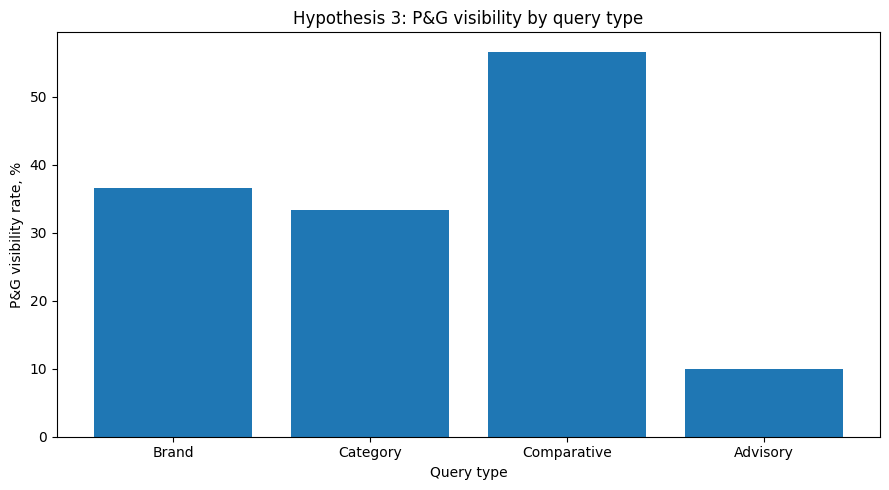

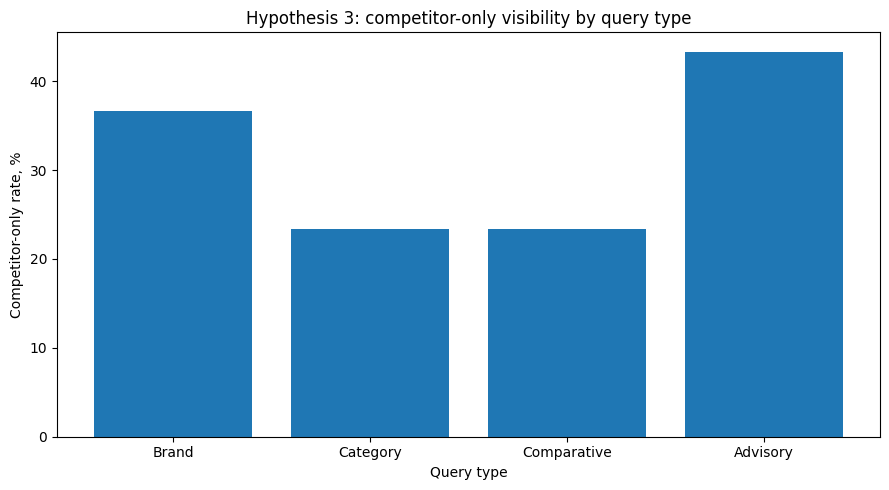

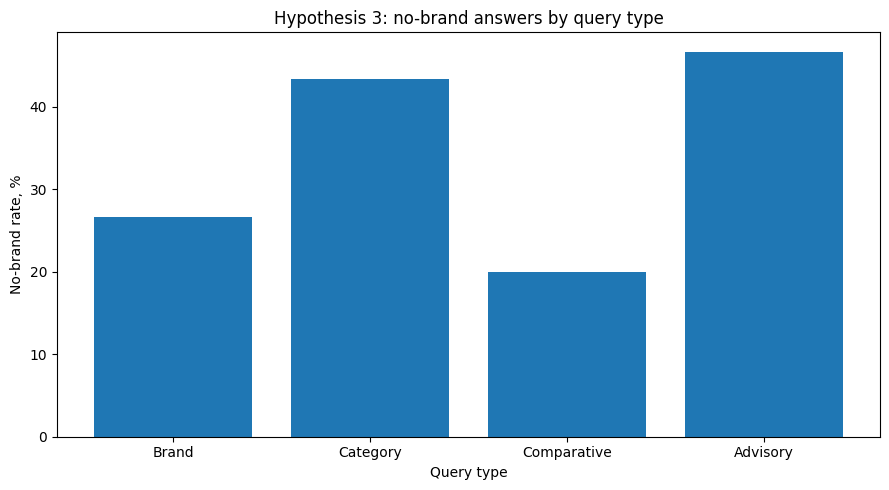

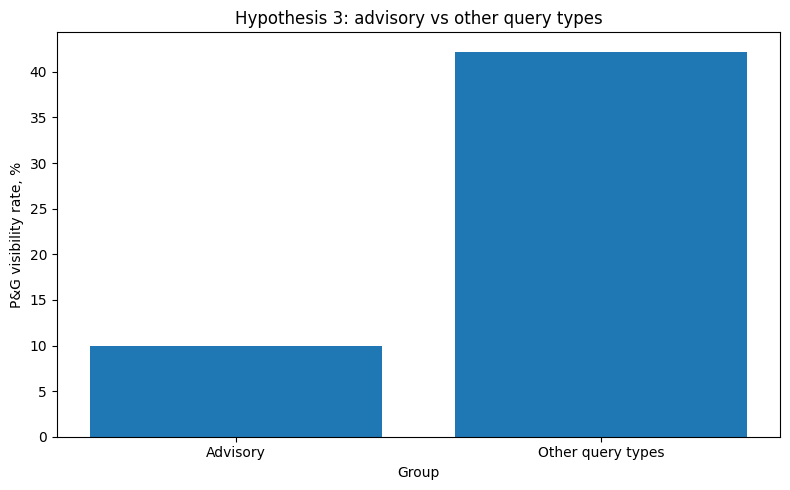

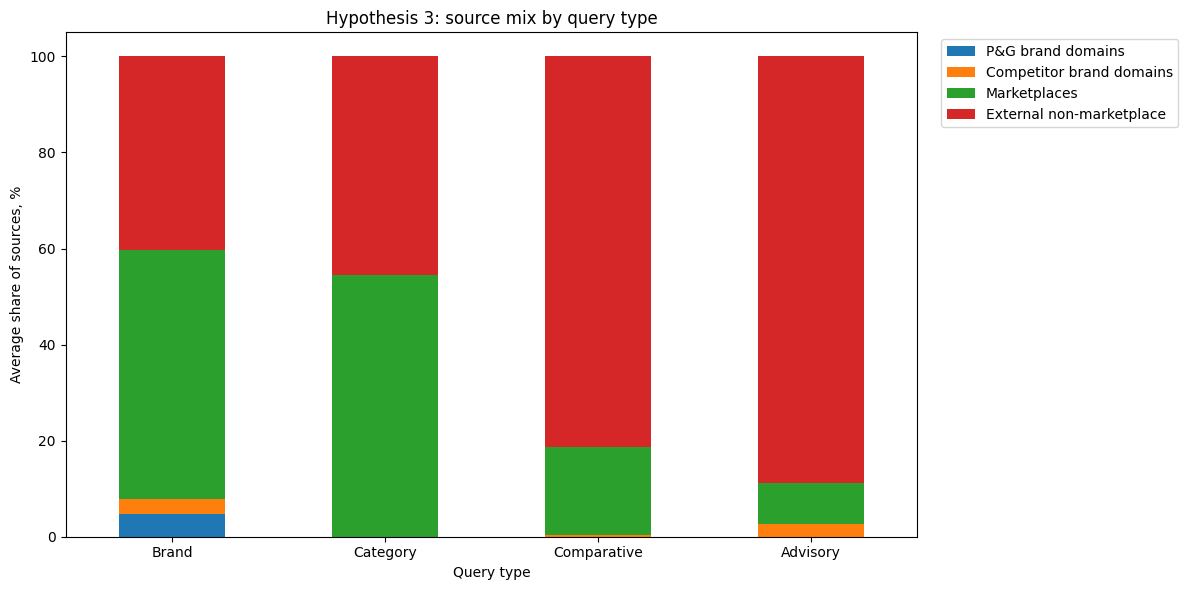

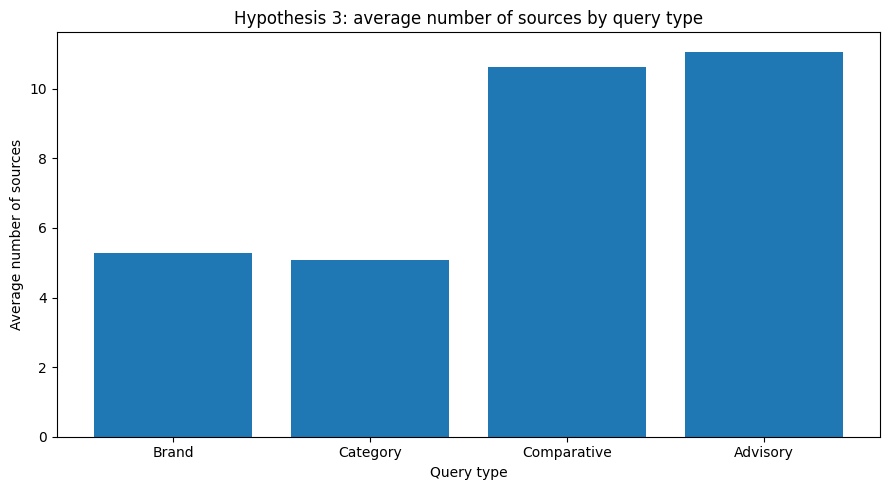

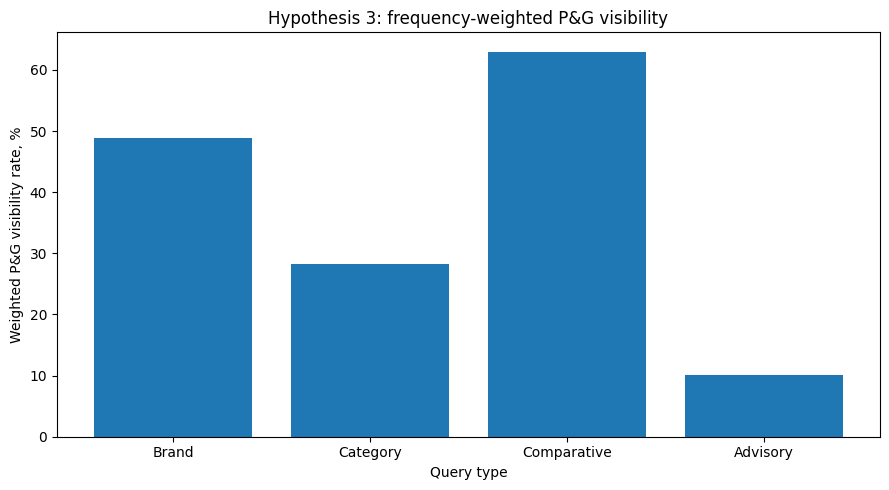

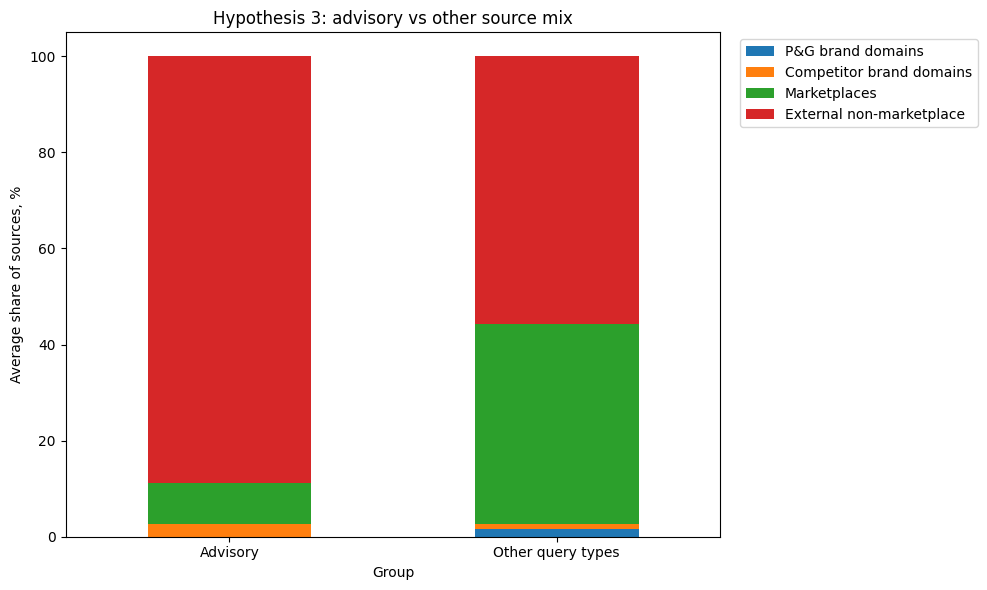

/var/folders/gx/lcw1qljx5pd86gphfq_pqzbc0000gn/T/ipykernel_6936/350102557.py:389: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([box_advisory, box_other], labels=['Advisory', 'Other query types'])


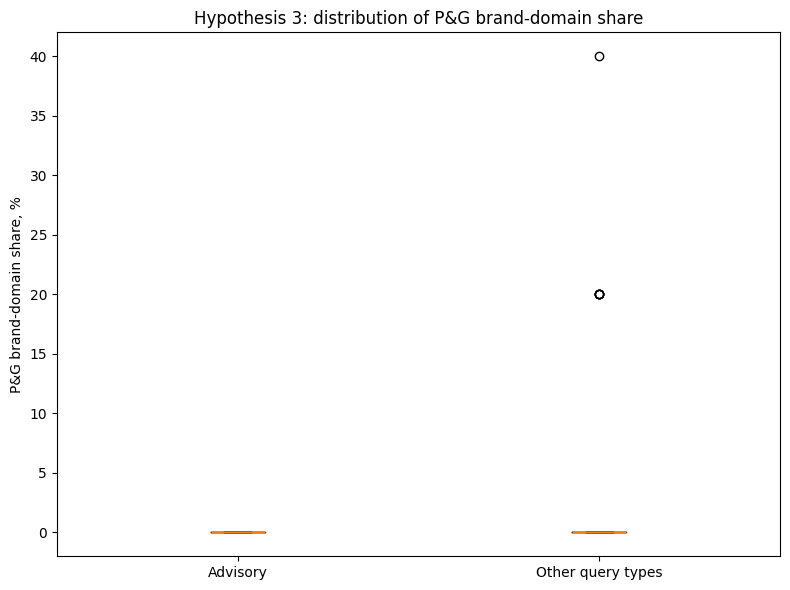


=== ADVISORY AREA SUMMARY ===
    Область  queries  pg_visibility_rate  competitor_only_rate  \
0   diapers       15                20.0                 46.67   
1  shampoos       15                 0.0                 40.00   

   no_brands_rate  avg_pg_brand_share_pct  avg_marketplace_share_pct  \
0           33.33                     0.0                      12.57   
1           60.00                     0.0                       4.71   

   avg_external_non_marketplace_share_pct  
0                                   82.33  
1                                   95.29  


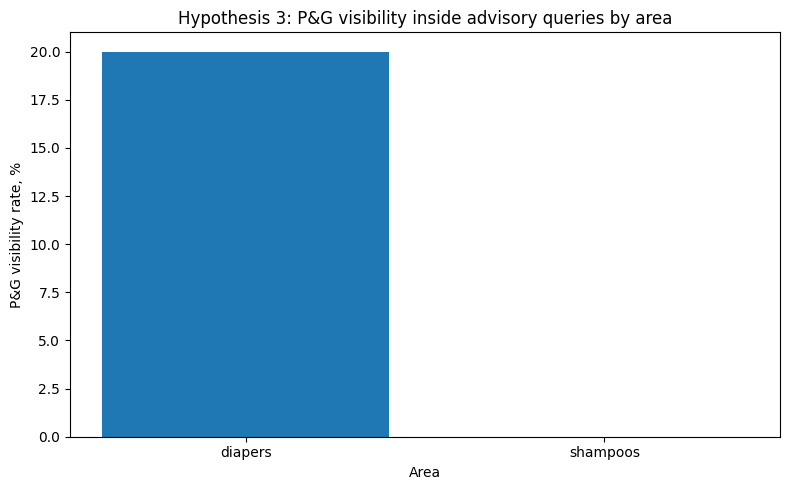


# Гипотеза 3. Основная слабость P&G проявляется именно в консультационных запросах

## Что проверяли
Проверялась идея о том, что **advisory-запросы** — это самый проблемный тип запросов для P&G, то есть именно в консультационных сценариях бренд реже попадает в генеративные ответы, чем в brand, category и comparative.

## Как проверяли
Все запросы были разделены на четыре типа:
- **brand**
- **category**
- **comparative**
- **advisory**

Для каждого типа считались:
- доля запросов, где виден **P&G**,
- доля запросов, где видны только **конкуренты**,
- доля ответов без брендов,
- среднее число источников,
- доля маркетплейсов,
- доля брендовых доменов P&G,
- доля внешних небредовых источников.

Дополнительно advisory сравнивался против всех остальных типов запросов как отдельный сегмент.

## Ключевые результаты
- **P&G visibility rate**:
  - **Brand:** 36.67%
  - **Category:** 33.33%
  - **Comparative:** 56.67%
  - **Advisory:** 10.00%

- **Frequency-weighted P&G visibility**:
  - **Bra

In [44]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 0. Папка для графиков
# =========================================
os.makedirs('graphs/h3', exist_ok=True)

def save_plot(filename: str):
    plt.tight_layout()
    plt.savefig(f'graphs/h3/{filename}', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# =========================================
# 1. Подготовка данных
# =========================================
df = combined_df.copy()

for col in ['P&G', 'Конкуренты', 'Маркетплейсы', 'Есть Алиса', 'Топ']:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(bool)

df['Текст Алисы'] = df['Текст Алисы'].fillna('').astype(str)
df['Категория'] = df['Категория'].astype(str).str.lower()
df['Область'] = df['Область'].astype(str).str.lower()

def define_brand_group(row):
    if row['P&G']:
        return 'p_and_g_present'
    elif row['Конкуренты']:
        return 'competitor_only'
    else:
        return 'no_brands'

df['brand_group'] = df.apply(define_brand_group, axis=1)

group_name_map = {
    'p_and_g_present': 'P&G visible',
    'competitor_only': 'Only competitors',
    'no_brands': 'No brands'
}

query_type_name_map = {
    'brand': 'Brand',
    'category': 'Category',
    'comparative': 'Comparative',
    'advisory': 'Advisory'
}

# =========================================
# 2. Разворачиваем источники
# =========================================
def normalize_site(site: str) -> str:
    site = str(site).strip().lower()
    site = site.replace('*', '')
    site = site.replace('\xa0', ' ')
    if site.startswith('http://'):
        site = site[len('http://'):]
    if site.startswith('https://'):
        site = site[len('https://'):]
    if site.startswith('www.'):
        site = site[len('www.'):]
    site = site.split('/')[0]
    return site.strip()

df['site_list'] = df['Текст Алисы'].str.split('\n')

sites_df = df.explode('site_list').copy()
sites_df['site'] = sites_df['site_list'].astype(str).str.strip()
sites_df = sites_df[sites_df['site'] != '']
sites_df = sites_df[sites_df['site'].str.lower() != 'nan']
sites_df['site'] = sites_df['site'].apply(normalize_site)
sites_df = sites_df[sites_df['site'] != '']

# =========================================
# 3. Простые proxy-признаки по источникам
# =========================================
marketplace_keywords = [
    'ozon', 'wildberries', 'market.yandex', 'detmir', 'votonia',
    'goldapple', 'letu', 'rivegauche', 'eapteka', 'akusherstvo',
    'megamarket'
]

pg_brand_keywords = [
    'pampers', 'oralb', 'oral-b', 'blendamed', 'blend-a-med',
    'headandshoulders', 'head-shoulders', 'pantene',
    'herbalessences', 'herbal-essences', 'oldspice', 'old-spice',
    'pg', 'procter'
]

competitor_brand_keywords = [
    'huggies', 'libero', 'elseve', 'loreal', 'clear', 'nivea',
    'syoss', 'schauma', 'johnson', 'johnsons'
]

def contains_any(text: str, keywords: list[str]) -> bool:
    text = str(text).lower()
    return any(k in text for k in keywords)

def is_ru_domain(site: str) -> bool:
    site = str(site).lower()
    return site.endswith('.ru') or site.endswith('.рф') or site.endswith('.su')

sites_df['is_marketplace'] = sites_df['site'].apply(lambda x: contains_any(x, marketplace_keywords))
sites_df['is_pg_brand_domain'] = sites_df['site'].apply(lambda x: contains_any(x, pg_brand_keywords))
sites_df['is_competitor_brand_domain'] = sites_df['site'].apply(lambda x: contains_any(x, competitor_brand_keywords))
sites_df['is_ru_domain'] = sites_df['site'].apply(is_ru_domain)

sites_df['is_external_non_marketplace'] = (
    (~sites_df['is_marketplace'])
    & (~sites_df['is_pg_brand_domain'])
    & (~sites_df['is_competitor_brand_domain'])
)

# =========================================
# 4. Метрики на уровне запроса
# =========================================
query_stats = (
    sites_df.groupby(['ID', 'Запрос', 'Категория', 'Область', 'Частота', 'brand_group'])
    .agg(
        total_sources=('site', 'count'),
        unique_sources=('site', 'nunique'),
        marketplace_sources=('is_marketplace', 'sum'),
        pg_brand_sources=('is_pg_brand_domain', 'sum'),
        competitor_brand_sources=('is_competitor_brand_domain', 'sum'),
        external_non_marketplace_sources=('is_external_non_marketplace', 'sum'),
        ru_sources=('is_ru_domain', 'sum')
    )
    .reset_index()
)

share_cols = [
    'marketplace_sources',
    'pg_brand_sources',
    'competitor_brand_sources',
    'external_non_marketplace_sources',
    'ru_sources'
]

for col in share_cols:
    query_stats[col.replace('_sources', '_share_pct')] = np.where(
        query_stats['total_sources'] > 0,
        query_stats[col] / query_stats['total_sources'] * 100,
        0
    )

query_stats['has_pg'] = query_stats['brand_group'] == 'p_and_g_present'
query_stats['has_competitor_only'] = query_stats['brand_group'] == 'competitor_only'
query_stats['has_no_brands'] = query_stats['brand_group'] == 'no_brands'

print(query_stats.head())

# =========================================
# 5. Сводка по типам запросов
# =========================================
type_summary = (
    query_stats.groupby('Категория')
    .agg(
        queries=('ID', 'count'),
        weighted_frequency=('Частота', 'sum'),
        pg_visibility_rate=('has_pg', 'mean'),
        competitor_only_rate=('has_competitor_only', 'mean'),
        no_brands_rate=('has_no_brands', 'mean'),
        avg_total_sources=('total_sources', 'mean'),
        avg_unique_sources=('unique_sources', 'mean'),
        avg_marketplace_share_pct=('marketplace_share_pct', 'mean'),
        avg_pg_brand_share_pct=('pg_brand_share_pct', 'mean'),
        avg_competitor_brand_share_pct=('competitor_brand_share_pct', 'mean'),
        avg_external_non_marketplace_share_pct=('external_non_marketplace_share_pct', 'mean'),
        avg_ru_share_pct=('ru_share_pct', 'mean')
    )
    .reset_index()
)

type_summary['pg_visibility_rate'] = (type_summary['pg_visibility_rate'] * 100).round(2)
type_summary['competitor_only_rate'] = (type_summary['competitor_only_rate'] * 100).round(2)
type_summary['no_brands_rate'] = (type_summary['no_brands_rate'] * 100).round(2)

for col in type_summary.columns:
    if col not in ['Категория', 'queries', 'weighted_frequency', 'pg_visibility_rate', 'competitor_only_rate', 'no_brands_rate']:
        type_summary[col] = type_summary[col].round(2)

print('=== TYPE SUMMARY ===')
print(type_summary)

# =========================================
# 6. Взвешенная по частоте сводка
# =========================================
weighted_type_summary = (
    query_stats.groupby('Категория')
    .apply(lambda g: pd.Series({
        'weighted_pg_visibility_rate': np.average((g['brand_group'] == 'p_and_g_present').astype(int), weights=g['Частота']) * 100,
        'weighted_marketplace_share_pct': np.average(g['marketplace_share_pct'], weights=g['Частота']),
        'weighted_pg_brand_share_pct': np.average(g['pg_brand_share_pct'], weights=g['Частота']),
        'weighted_competitor_brand_share_pct': np.average(g['competitor_brand_share_pct'], weights=g['Частота']),
        'weighted_external_non_marketplace_share_pct': np.average(g['external_non_marketplace_share_pct'], weights=g['Частота'])
    }))
    .reset_index()
)

for col in weighted_type_summary.columns:
    if col != 'Категория':
        weighted_type_summary[col] = weighted_type_summary[col].round(2)

print('\n=== WEIGHTED TYPE SUMMARY ===')
print(weighted_type_summary)

plot_df = type_summary.merge(weighted_type_summary, on='Категория', how='left')
plot_df['query_type_label'] = plot_df['Категория'].map(query_type_name_map)

# =========================================
# 7. Отдельная advisory-таблица против остальных
# =========================================
query_stats['is_advisory'] = query_stats['Категория'] == 'advisory'
query_stats['advisory_vs_other'] = np.where(query_stats['is_advisory'], 'Advisory', 'Other query types')

adv_vs_other = (
    query_stats.groupby('advisory_vs_other')
    .agg(
        queries=('ID', 'count'),
        weighted_frequency=('Частота', 'sum'),
        pg_visibility_rate=('has_pg', 'mean'),
        competitor_only_rate=('has_competitor_only', 'mean'),
        no_brands_rate=('has_no_brands', 'mean'),
        avg_total_sources=('total_sources', 'mean'),
        avg_marketplace_share_pct=('marketplace_share_pct', 'mean'),
        avg_pg_brand_share_pct=('pg_brand_share_pct', 'mean'),
        avg_competitor_brand_share_pct=('competitor_brand_share_pct', 'mean'),
        avg_external_non_marketplace_share_pct=('external_non_marketplace_share_pct', 'mean')
    )
    .reset_index()
)

adv_vs_other['pg_visibility_rate'] = (adv_vs_other['pg_visibility_rate'] * 100).round(2)
adv_vs_other['competitor_only_rate'] = (adv_vs_other['competitor_only_rate'] * 100).round(2)
adv_vs_other['no_brands_rate'] = (adv_vs_other['no_brands_rate'] * 100).round(2)

for col in adv_vs_other.columns:
    if col not in ['advisory_vs_other', 'queries', 'weighted_frequency', 'pg_visibility_rate', 'competitor_only_rate', 'no_brands_rate']:
        adv_vs_other[col] = adv_vs_other[col].round(2)

print('\n=== ADVISORY VS OTHER ===')
print(adv_vs_other)

# =========================================
# 8. График 1. Видимость P&G по типам запросов
# =========================================
plot1 = plot_df.set_index('query_type_label')['pg_visibility_rate'].reindex(
    ['Brand', 'Category', 'Comparative', 'Advisory']
)

plt.figure(figsize=(9, 5))
plt.bar(plot1.index, plot1.values)
plt.title('Hypothesis 3: P&G visibility by query type')
plt.xlabel('Query type')
plt.ylabel('P&G visibility rate, %')
save_plot('h3_pg_visibility_by_query_type.png')

# =========================================
# 9. График 2. Competitor only rate по типам запросов
# =========================================
plot2 = plot_df.set_index('query_type_label')['competitor_only_rate'].reindex(
    ['Brand', 'Category', 'Comparative', 'Advisory']
)

plt.figure(figsize=(9, 5))
plt.bar(plot2.index, plot2.values)
plt.title('Hypothesis 3: competitor-only visibility by query type')
plt.xlabel('Query type')
plt.ylabel('Competitor-only rate, %')
save_plot('h3_competitor_only_by_query_type.png')

# =========================================
# 10. График 3. No brands rate по типам запросов
# =========================================
plot3 = plot_df.set_index('query_type_label')['no_brands_rate'].reindex(
    ['Brand', 'Category', 'Comparative', 'Advisory']
)

plt.figure(figsize=(9, 5))
plt.bar(plot3.index, plot3.values)
plt.title('Hypothesis 3: no-brand answers by query type')
plt.xlabel('Query type')
plt.ylabel('No-brand rate, %')
save_plot('h3_no_brands_by_query_type.png')

# =========================================
# 11. График 4. Advisory vs others: P&G visibility
# =========================================
plt.figure(figsize=(8, 5))
plt.bar(adv_vs_other['advisory_vs_other'], adv_vs_other['pg_visibility_rate'])
plt.title('Hypothesis 3: advisory vs other query types')
plt.xlabel('Group')
plt.ylabel('P&G visibility rate, %')
save_plot('h3_advisory_vs_other_pg_visibility.png')

# =========================================
# 12. График 5. Структура источников по типам запросов
# =========================================
source_mix_df = plot_df.set_index('query_type_label')[
    [
        'avg_pg_brand_share_pct',
        'avg_competitor_brand_share_pct',
        'avg_marketplace_share_pct',
        'avg_external_non_marketplace_share_pct'
    ]
].reindex(['Brand', 'Category', 'Comparative', 'Advisory'])

source_mix_df.columns = [
    'P&G brand domains',
    'Competitor brand domains',
    'Marketplaces',
    'External non-marketplace'
]

source_mix_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Hypothesis 3: source mix by query type')
plt.xlabel('Query type')
plt.ylabel('Average share of sources, %')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h3_source_mix_by_query_type.png')

# =========================================
# 13. График 6. Среднее число источников по типам запросов
# =========================================
plot6 = plot_df.set_index('query_type_label')['avg_total_sources'].reindex(
    ['Brand', 'Category', 'Comparative', 'Advisory']
)

plt.figure(figsize=(9, 5))
plt.bar(plot6.index, plot6.values)
plt.title('Hypothesis 3: average number of sources by query type')
plt.xlabel('Query type')
plt.ylabel('Average number of sources')
save_plot('h3_avg_sources_by_query_type.png')

# =========================================
# 14. График 7. Взвешенная видимость P&G
# =========================================
plot7 = plot_df.set_index('query_type_label')['weighted_pg_visibility_rate'].reindex(
    ['Brand', 'Category', 'Comparative', 'Advisory']
)

plt.figure(figsize=(9, 5))
plt.bar(plot7.index, plot7.values)
plt.title('Hypothesis 3: frequency-weighted P&G visibility')
plt.xlabel('Query type')
plt.ylabel('Weighted P&G visibility rate, %')
save_plot('h3_weighted_pg_visibility_by_query_type.png')

# =========================================
# 15. График 8. Advisory vs other: source structure
# =========================================
adv_plot = adv_vs_other.set_index('advisory_vs_other')[
    [
        'avg_pg_brand_share_pct',
        'avg_competitor_brand_share_pct',
        'avg_marketplace_share_pct',
        'avg_external_non_marketplace_share_pct'
    ]
]

adv_plot.columns = [
    'P&G brand domains',
    'Competitor brand domains',
    'Marketplaces',
    'External non-marketplace'
]

adv_plot.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Hypothesis 3: advisory vs other source mix')
plt.xlabel('Group')
plt.ylabel('Average share of sources, %')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h3_advisory_vs_other_source_mix.png')

# =========================================
# 16. График 9. Boxplot: advisory vs other P&G-brand share
# =========================================
box_advisory = query_stats.loc[query_stats['advisory_vs_other'] == 'Advisory', 'pg_brand_share_pct']
box_other = query_stats.loc[query_stats['advisory_vs_other'] == 'Other query types', 'pg_brand_share_pct']

plt.figure(figsize=(8, 6))
plt.boxplot([box_advisory, box_other], labels=['Advisory', 'Other query types'])
plt.title('Hypothesis 3: distribution of P&G brand-domain share')
plt.ylabel('P&G brand-domain share, %')
save_plot('h3_boxplot_pg_brand_share_advisory_vs_other.png')

# =========================================
# 17. График 10. Срез по областям внутри advisory
# =========================================
advisory_area = query_stats[query_stats['Категория'] == 'advisory'].copy()

advisory_area_summary = (
    advisory_area.groupby('Область')
    .agg(
        queries=('ID', 'count'),
        pg_visibility_rate=('has_pg', 'mean'),
        competitor_only_rate=('has_competitor_only', 'mean'),
        no_brands_rate=('has_no_brands', 'mean'),
        avg_pg_brand_share_pct=('pg_brand_share_pct', 'mean'),
        avg_marketplace_share_pct=('marketplace_share_pct', 'mean'),
        avg_external_non_marketplace_share_pct=('external_non_marketplace_share_pct', 'mean')
    )
    .reset_index()
)

advisory_area_summary['pg_visibility_rate'] = (advisory_area_summary['pg_visibility_rate'] * 100).round(2)
advisory_area_summary['competitor_only_rate'] = (advisory_area_summary['competitor_only_rate'] * 100).round(2)
advisory_area_summary['no_brands_rate'] = (advisory_area_summary['no_brands_rate'] * 100).round(2)

for col in advisory_area_summary.columns:
    if col not in ['Область', 'queries', 'pg_visibility_rate', 'competitor_only_rate', 'no_brands_rate']:
        advisory_area_summary[col] = advisory_area_summary[col].round(2)

print('\n=== ADVISORY AREA SUMMARY ===')
print(advisory_area_summary)

plt.figure(figsize=(8, 5))
plt.bar(advisory_area_summary['Область'], advisory_area_summary['pg_visibility_rate'])
plt.title('Hypothesis 3: P&G visibility inside advisory queries by area')
plt.xlabel('Area')
plt.ylabel('P&G visibility rate, %')
save_plot('h3_advisory_pg_visibility_by_area.png')

# =========================================
# 18. Сохраняем таблицы
# =========================================
type_summary.to_excel('graphs/h3/h3_type_summary.xlsx', index=False)
weighted_type_summary.to_excel('graphs/h3/h3_weighted_type_summary.xlsx', index=False)
adv_vs_other.to_excel('graphs/h3/h3_advisory_vs_other.xlsx', index=False)
query_stats.to_excel('graphs/h3/h3_query_stats.xlsx', index=False)
advisory_area_summary.to_excel('graphs/h3/h3_advisory_area_summary.xlsx', index=False)

# =========================================
# 19. Markdown-вывод
# =========================================
advisory_row = plot_df[plot_df['Категория'] == 'advisory'].iloc[0]
brand_row = plot_df[plot_df['Категория'] == 'brand'].iloc[0]
category_row = plot_df[plot_df['Категория'] == 'category'].iloc[0]
comparative_row = plot_df[plot_df['Категория'] == 'comparative'].iloc[0]

adv_pg = float(advisory_row['pg_visibility_rate'])
brand_pg = float(brand_row['pg_visibility_rate'])
cat_pg = float(category_row['pg_visibility_rate'])
comp_pg = float(comparative_row['pg_visibility_rate'])

adv_pg_weighted = float(advisory_row['weighted_pg_visibility_rate'])
brand_pg_weighted = float(brand_row['weighted_pg_visibility_rate'])
cat_pg_weighted = float(category_row['weighted_pg_visibility_rate'])
comp_pg_weighted = float(comparative_row['weighted_pg_visibility_rate'])

adv_market = float(advisory_row['avg_marketplace_share_pct'])
adv_ext = float(advisory_row['avg_external_non_marketplace_share_pct'])
adv_pg_brand = float(advisory_row['avg_pg_brand_share_pct'])
adv_comp_brand = float(advisory_row['avg_competitor_brand_share_pct'])

if adv_pg < brand_pg and adv_pg < cat_pg and adv_pg < comp_pg and adv_pg_weighted < brand_pg_weighted and adv_pg_weighted < cat_pg_weighted and adv_pg_weighted < comp_pg_weighted:
    verdict = 'Гипотеза скорее подтверждается'
    explanation = (
        'advisory-запросы действительно оказываются самым слабым типом запросов для P&G: '
        'видимость бренда здесь ниже, чем в brand, category и comparative.'
    )
elif adv_pg >= min(brand_pg, cat_pg, comp_pg):
    verdict = 'Гипотеза скорее не подтверждается'
    explanation = (
        'advisory-запросы не выглядят самым слабым типом для P&G; '
        'слабая видимость бренда распределена шире и не концентрируется только в консультационном слое.'
    )
else:
    verdict = 'Гипотеза подтверждается частично'
    explanation = (
        'в advisory-запросах видимость P&G ниже части других типов запросов, '
        'но не по всем метрикам advisory оказывается самым проблемным сегментом.'
    )

markdown_report = f"""
# Гипотеза 3. Основная слабость P&G проявляется именно в консультационных запросах

## Что проверяли
Проверялась идея о том, что **advisory-запросы** — это самый проблемный тип запросов для P&G, то есть именно в консультационных сценариях бренд реже попадает в генеративные ответы, чем в brand, category и comparative.

## Как проверяли
Все запросы были разделены на четыре типа:
- **brand**
- **category**
- **comparative**
- **advisory**

Для каждого типа считались:
- доля запросов, где виден **P&G**,
- доля запросов, где видны только **конкуренты**,
- доля ответов без брендов,
- среднее число источников,
- доля маркетплейсов,
- доля брендовых доменов P&G,
- доля внешних небредовых источников.

Дополнительно advisory сравнивался против всех остальных типов запросов как отдельный сегмент.

## Ключевые результаты
- **P&G visibility rate**:
  - **Brand:** {brand_pg:.2f}%
  - **Category:** {cat_pg:.2f}%
  - **Comparative:** {comp_pg:.2f}%
  - **Advisory:** {adv_pg:.2f}%

- **Frequency-weighted P&G visibility**:
  - **Brand:** {brand_pg_weighted:.2f}%
  - **Category:** {cat_pg_weighted:.2f}%
  - **Comparative:** {comp_pg_weighted:.2f}%
  - **Advisory:** {adv_pg_weighted:.2f}%

- Для **advisory** средняя структура источников:
  - **P&G brand domains:** {adv_pg_brand:.2f}%
  - **Competitor brand domains:** {adv_comp_brand:.2f}%
  - **Marketplaces:** {adv_market:.2f}%
  - **External non-marketplace:** {adv_ext:.2f}%

## Интерпретация
**{verdict}.** Это означает, что {explanation}

Если advisory одновременно показывает низкую долю брендовых доменов P&G и высокую долю внешних небредовых источников, это поддерживает идею, что консультационный слой особенно зависит от внешней recommendation-среды, где P&G представлена недостаточно сильно.

## Ограничение метода
Это proxy-анализ по `combined_df`.  
Мы не оцениваем качество ответа модели и не анализируем содержание страниц вручную.  
Поэтому вывод касается именно **структуры генеративной выдачи**, а не полного качества контентной экосистемы бренда.

## Практический вывод для кейса
Если гипотеза подтверждается, то advisory-запросы нужно считать отдельной зоной роста для P&G.  
Это означает, что усиливать нужно не только брендовое присутствие, но и сценарии problem-solving выбора:
- советы,
- подборки,
- объясняющий контент,
- how-to сценарии,
- ответы на пользовательские боли,
- внешние площадки, которые формируют recommendation layer.

Если гипотеза не подтверждается, то проблему видимости следует искать шире — не только в консультационных запросах, а в category/comparative слоях или в общей структуре source mix.
"""

print(markdown_report)

   ID                Запрос Категория  Область  Частота      brand_group  \
0   1               памперс     brand  diapers   850000  p_and_g_present   
1   2               pampers     brand  diapers   620000  p_and_g_present   
2   3       памперс трусики     brand  diapers   320000  p_and_g_present   
3   4  pampers premium care     brand  diapers   280000  p_and_g_present   
4   5   памперс active baby     brand  diapers   250000  p_and_g_present   

   total_sources  marketplace_sources  marketplace_share_pct  unique_domains  \
0              5                    3                   60.0               5   
1              5                    3                   60.0               5   
2              5                    4                   80.0               5   
3              5                    3                   60.0               5   
4              5                    2                   40.0               5   

   top1_domain_share_pct  top3_domains_share_pct  repetition_s

/var/folders/gx/lcw1qljx5pd86gphfq_pqzbc0000gn/T/ipykernel_6936/1372674901.py:186: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


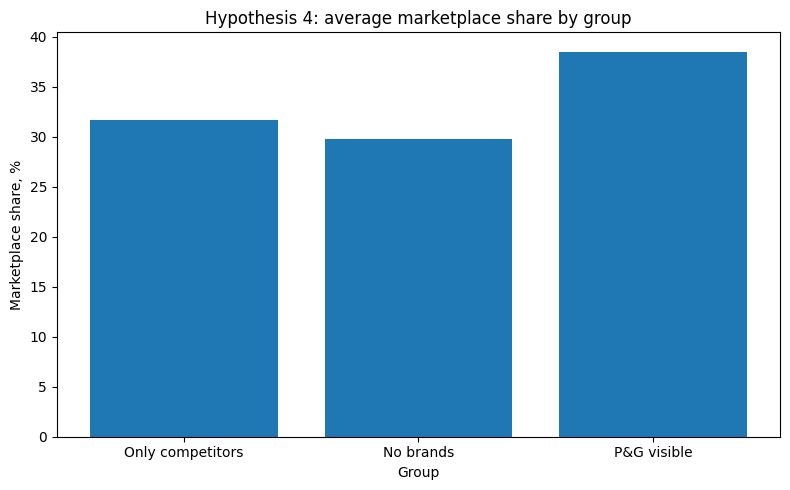

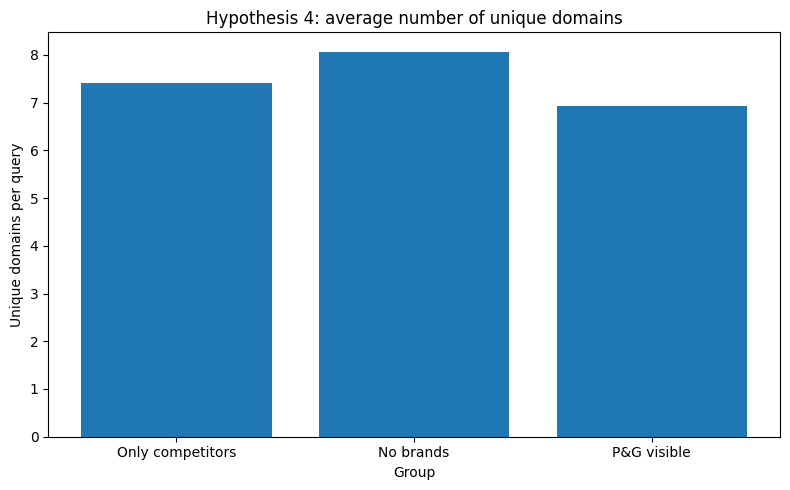

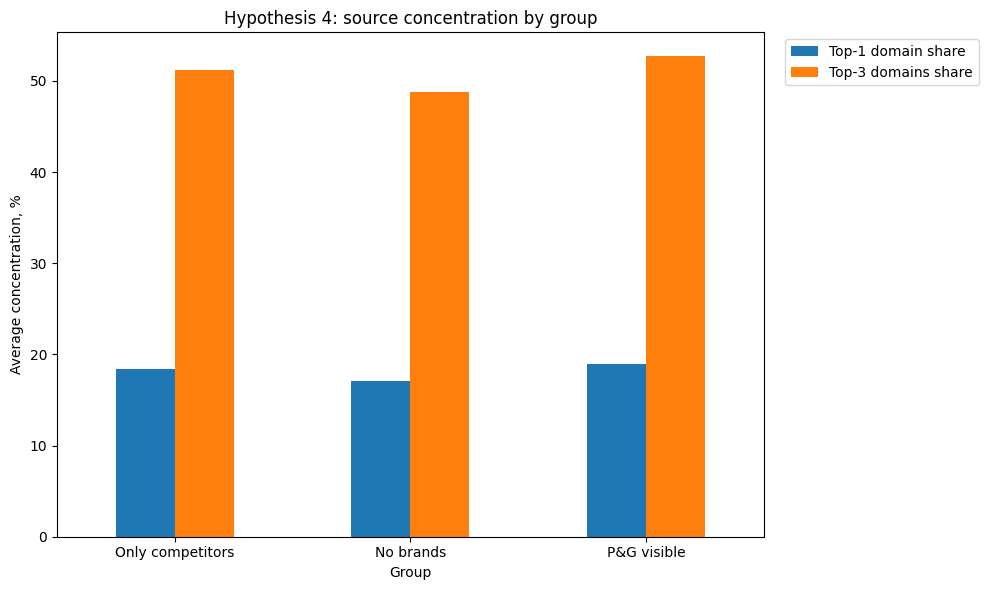

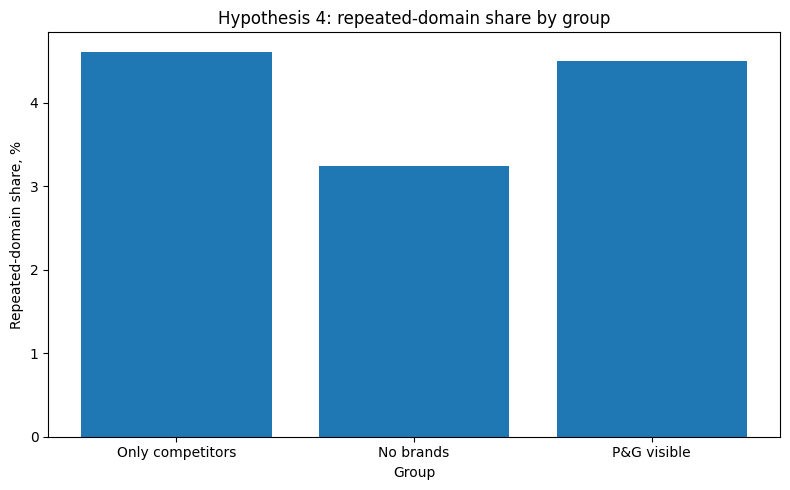

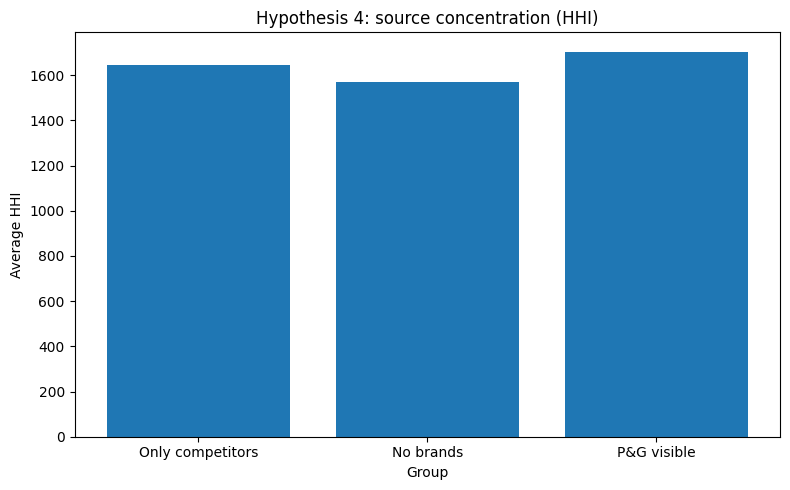

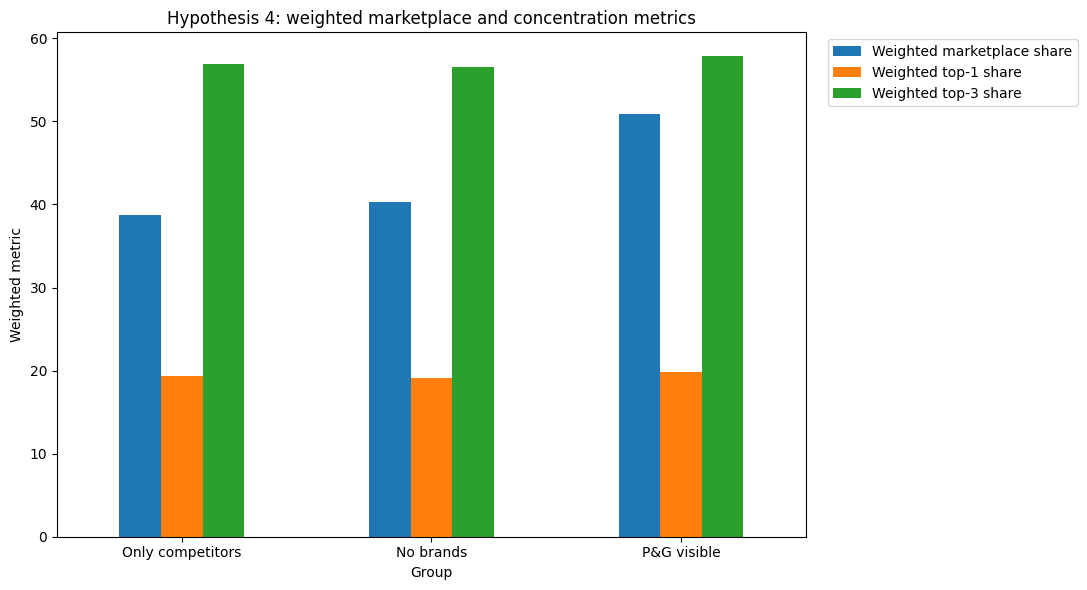

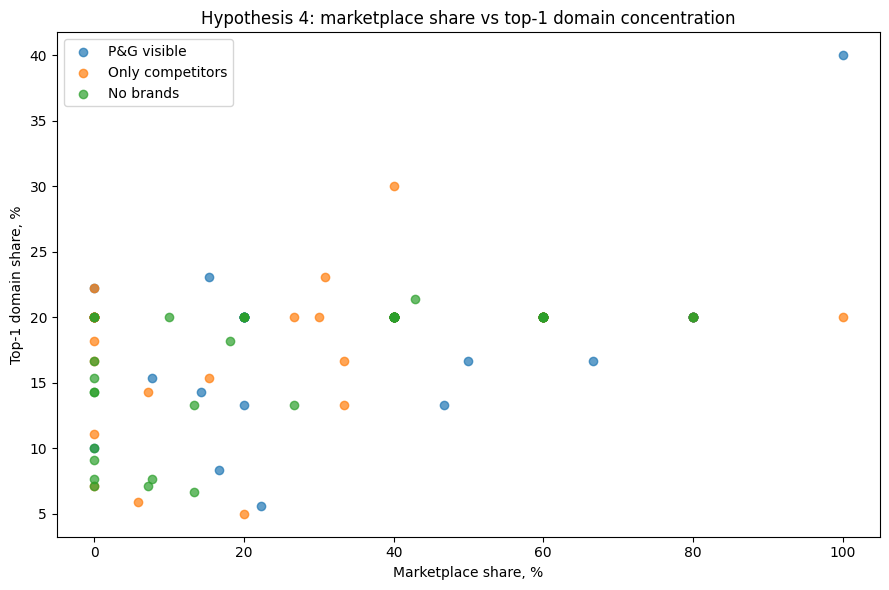

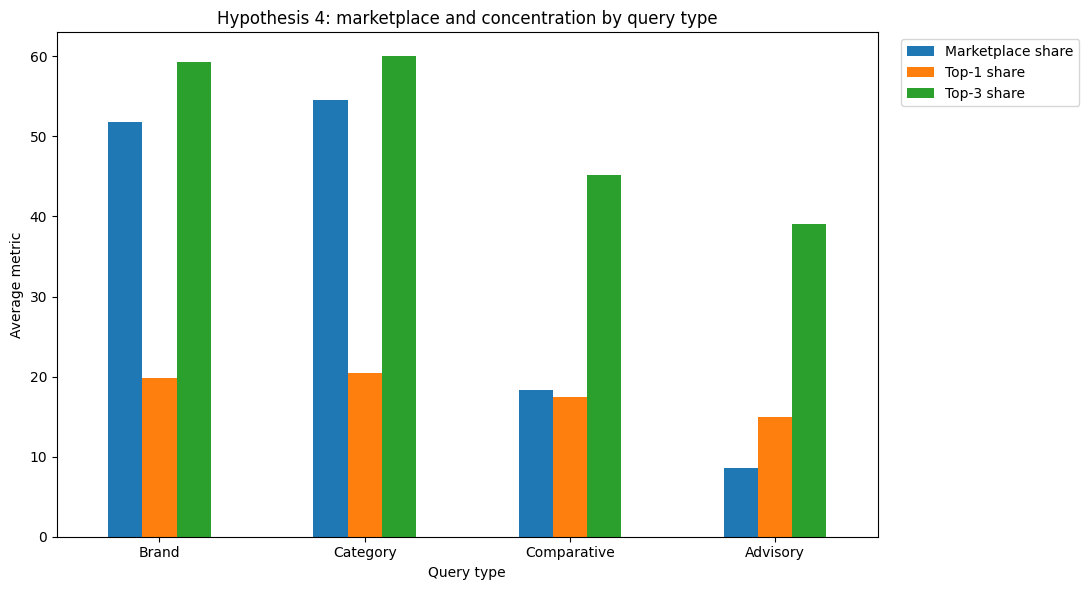

/var/folders/gx/lcw1qljx5pd86gphfq_pqzbc0000gn/T/ipykernel_6936/1372674901.py:350: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_groups, labels=['P&G visible', 'Only competitors', 'No brands'])


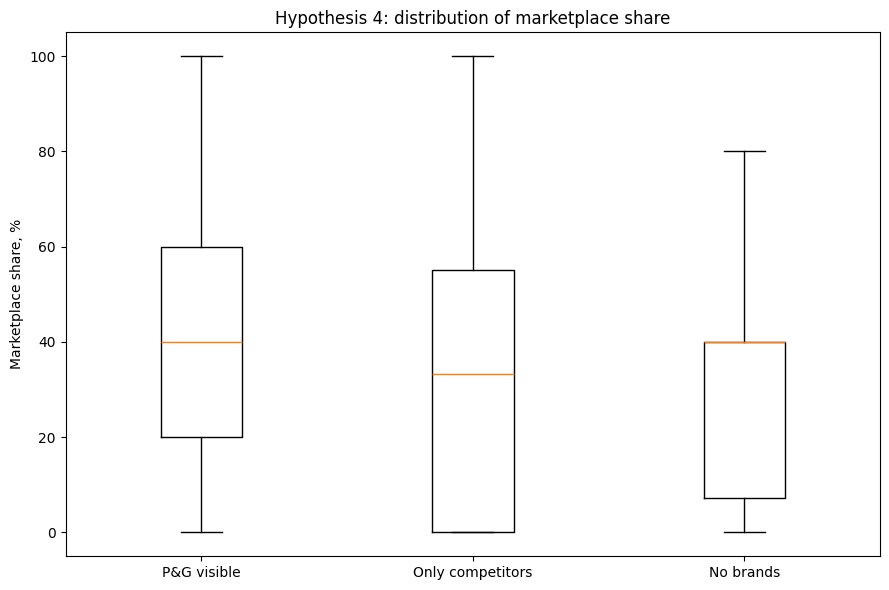

/var/folders/gx/lcw1qljx5pd86gphfq_pqzbc0000gn/T/ipykernel_6936/1372674901.py:365: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_groups_top1, labels=['P&G visible', 'Only competitors', 'No brands'])


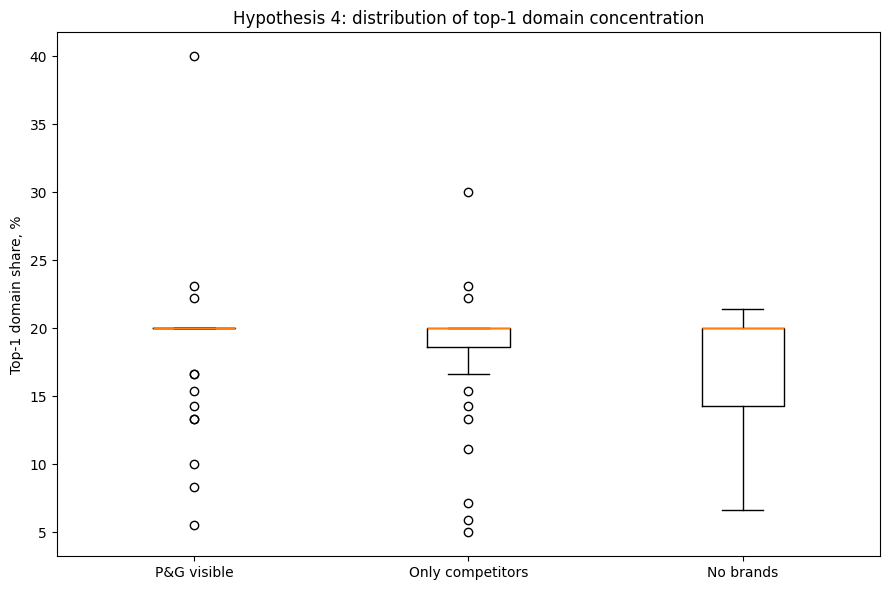

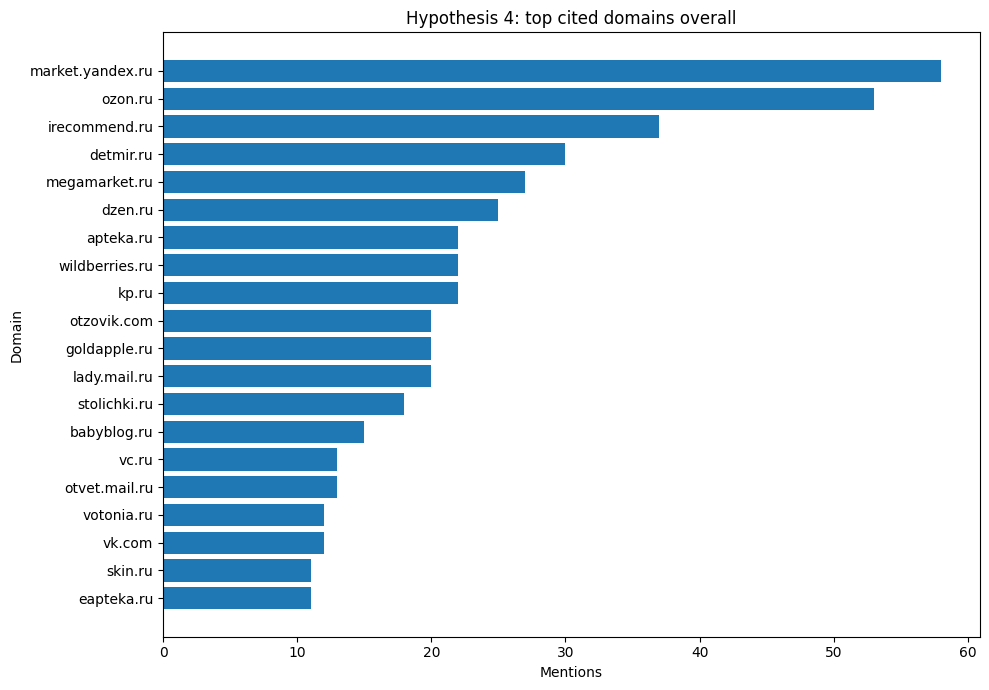


# Гипотеза 4. Видимость P&G ослабляется из-за доминирования маркетплейсов и низкой диверсификации источников

## Что проверяли
Проверялась идея о том, что низкая видимость P&G связана сразу с двумя факторами:
1. генеративная выдача слишком сильно опирается на маркетплейсы;
2. источники, на которых держится ответ, недостаточно диверсифицированы и слишком концентрированы вокруг небольшого числа доменов.

## Как проверяли
Для каждого запроса были рассчитаны:
- **marketplace share** — доля маркетплейсов среди источников,
- **unique domains** — число уникальных доменов,
- **top-1 domain share** — доля самого часто встречающегося домена,
- **top-3 domains share** — доля трёх крупнейших доменов,
- **repetition share** — доля повторов доменов,
- **HHI** как мера концентрации.

Затем сравнивались три группы запросов:
- **P&G visible**
- **Only competitors**
- **No brands**

## Ключевые результаты
- Средняя доля маркетплейсов:
  - **P&G visible:** 38.53%
  - **Only competitors:** 31.65%
  - **N

In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 0. Папка для графиков
# =========================================
os.makedirs('graphs/h4', exist_ok=True)

def save_plot(filename: str):
    plt.tight_layout()
    plt.savefig(f'graphs/h4/{filename}', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# =========================================
# 1. Подготовка данных
# =========================================
df = combined_df.copy()

for col in ['P&G', 'Конкуренты', 'Маркетплейсы', 'Есть Алиса', 'Топ']:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(bool)

df['Текст Алисы'] = df['Текст Алисы'].fillna('').astype(str)
df['Категория'] = df['Категория'].astype(str).str.lower()
df['Область'] = df['Область'].astype(str).str.lower()

def define_brand_group(row):
    if row['P&G']:
        return 'p_and_g_present'
    elif row['Конкуренты']:
        return 'competitor_only'
    else:
        return 'no_brands'

df['brand_group'] = df.apply(define_brand_group, axis=1)

group_name_map = {
    'p_and_g_present': 'P&G visible',
    'competitor_only': 'Only competitors',
    'no_brands': 'No brands'
}

# =========================================
# 2. Разворачиваем домены
# =========================================
def normalize_site(site: str) -> str:
    site = str(site).strip().lower()
    site = site.replace('*', '')
    site = site.replace('\xa0', ' ')
    if site.startswith('http://'):
        site = site[len('http://'):]
    if site.startswith('https://'):
        site = site[len('https://'):]
    if site.startswith('www.'):
        site = site[len('www.'):]
    site = site.split('/')[0]
    return site.strip()

df['site_list'] = df['Текст Алисы'].str.split('\n')

sites_df = df.explode('site_list').copy()
sites_df['site'] = sites_df['site_list'].astype(str).str.strip()
sites_df = sites_df[sites_df['site'] != '']
sites_df = sites_df[sites_df['site'].str.lower() != 'nan']
sites_df['site'] = sites_df['site'].apply(normalize_site)
sites_df = sites_df[sites_df['site'] != '']

# =========================================
# 3. Marketplace proxy
# =========================================
marketplace_keywords = [
    'ozon', 'wildberries', 'market.yandex', 'detmir', 'votonia',
    'goldapple', 'letu', 'rivegauche', 'eapteka', 'akusherstvo',
    'megamarket', 'sbermegamarket'
]

def contains_any(text: str, keywords: list[str]) -> bool:
    text = str(text).lower()
    return any(k in text for k in keywords)

sites_df['is_marketplace'] = sites_df['site'].apply(lambda x: contains_any(x, marketplace_keywords))

# =========================================
# 4. Метрики концентрации на уровне запроса
# =========================================
# частоты доменов внутри запроса
domain_counts = (
    sites_df.groupby(['ID', 'site'])
    .size()
    .reset_index(name='domain_count')
)

# агрегаты по запросу
query_domain_concentration = []

for query_id, part in domain_counts.groupby('ID'):
    counts = part['domain_count'].sort_values(ascending=False).values
    total = counts.sum()
    unique_domains = len(counts)

    top1_share = counts[0] / total * 100 if total > 0 else 0
    top3_share = counts[:3].sum() / total * 100 if total > 0 else 0
    repeated_sources = total - unique_domains
    repetition_share = repeated_sources / total * 100 if total > 0 else 0

    query_domain_concentration.append({
        'ID': query_id,
        'unique_domains': unique_domains,
        'top1_domain_share_pct': round(top1_share, 2),
        'top3_domains_share_pct': round(top3_share, 2),
        'repetition_share_pct': round(repetition_share, 2)
    })

concentration_df = pd.DataFrame(query_domain_concentration)

# =========================================
# 5. Базовые query-level метрики
# =========================================
query_stats = (
    sites_df.groupby(['ID', 'Запрос', 'Категория', 'Область', 'Частота', 'brand_group'])
    .agg(
        total_sources=('site', 'count'),
        marketplace_sources=('is_marketplace', 'sum')
    )
    .reset_index()
)

query_stats['marketplace_share_pct'] = np.where(
    query_stats['total_sources'] > 0,
    query_stats['marketplace_sources'] / query_stats['total_sources'] * 100,
    0
)

query_stats = query_stats.merge(concentration_df, on='ID', how='left')

# hhi-like metric
# sum(p_i^2) * 10000
hhi_rows = []
for query_id, part in domain_counts.groupby('ID'):
    counts = part['domain_count'].values
    total = counts.sum()
    shares = counts / total if total > 0 else np.array([0])
    hhi = (shares ** 2).sum() * 10000
    hhi_rows.append({'ID': query_id, 'hhi': round(float(hhi), 2)})

hhi_df = pd.DataFrame(hhi_rows)
query_stats = query_stats.merge(hhi_df, on='ID', how='left')

print(query_stats.head())

# =========================================
# 6. Сводка по группам
# =========================================
group_summary = (
    query_stats.groupby('brand_group')
    .agg(
        queries=('ID', 'count'),
        weighted_frequency=('Частота', 'sum'),
        avg_marketplace_share_pct=('marketplace_share_pct', 'mean'),
        median_marketplace_share_pct=('marketplace_share_pct', 'median'),
        avg_total_sources=('total_sources', 'mean'),
        avg_unique_domains=('unique_domains', 'mean'),
        avg_top1_domain_share_pct=('top1_domain_share_pct', 'mean'),
        avg_top3_domains_share_pct=('top3_domains_share_pct', 'mean'),
        avg_repetition_share_pct=('repetition_share_pct', 'mean'),
        avg_hhi=('hhi', 'mean')
    )
    .reset_index()
)

for col in group_summary.columns:
    if col not in ['brand_group', 'queries', 'weighted_frequency']:
        group_summary[col] = group_summary[col].round(2)

print('=== GROUP SUMMARY ===')
print(group_summary)

# =========================================
# 7. Взвешенная по частоте сводка
# =========================================
weighted_summary = (
    query_stats.groupby('brand_group')
    .apply(lambda g: pd.Series({
        'weighted_marketplace_share_pct': np.average(g['marketplace_share_pct'], weights=g['Частота']),
        'weighted_unique_domains': np.average(g['unique_domains'], weights=g['Частота']),
        'weighted_top1_domain_share_pct': np.average(g['top1_domain_share_pct'], weights=g['Частота']),
        'weighted_top3_domains_share_pct': np.average(g['top3_domains_share_pct'], weights=g['Частота']),
        'weighted_repetition_share_pct': np.average(g['repetition_share_pct'], weights=g['Частота']),
        'weighted_hhi': np.average(g['hhi'], weights=g['Частота'])
    }))
    .reset_index()
)

for col in weighted_summary.columns:
    if col != 'brand_group':
        weighted_summary[col] = weighted_summary[col].round(2)

print('\n=== WEIGHTED SUMMARY ===')
print(weighted_summary)

plot_df = group_summary.merge(weighted_summary, on='brand_group', how='left')
plot_df['brand_group_label'] = plot_df['brand_group'].map(group_name_map)
query_stats['brand_group_label'] = query_stats['brand_group'].map(group_name_map)

# =========================================
# 8. График 1. Marketplace share по группам
# =========================================
plt.figure(figsize=(8, 5))
plt.bar(plot_df['brand_group_label'], plot_df['avg_marketplace_share_pct'])
plt.title('Hypothesis 4: average marketplace share by group')
plt.xlabel('Group')
plt.ylabel('Marketplace share, %')
plt.xticks(rotation=0)
save_plot('h4_marketplace_share_by_group.png')

# =========================================
# 9. График 2. Уникальные домены по группам
# =========================================
plt.figure(figsize=(8, 5))
plt.bar(plot_df['brand_group_label'], plot_df['avg_unique_domains'])
plt.title('Hypothesis 4: average number of unique domains')
plt.xlabel('Group')
plt.ylabel('Unique domains per query')
plt.xticks(rotation=0)
save_plot('h4_unique_domains_by_group.png')

# =========================================
# 10. График 3. Концентрация top-1 и top-3
# =========================================
concentration_plot = plot_df.set_index('brand_group_label')[
    ['avg_top1_domain_share_pct', 'avg_top3_domains_share_pct']
]
concentration_plot.columns = ['Top-1 domain share', 'Top-3 domains share']

concentration_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Hypothesis 4: source concentration by group')
plt.xlabel('Group')
plt.ylabel('Average concentration, %')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h4_source_concentration_by_group.png')

# =========================================
# 11. График 4. Repetition share
# =========================================
plt.figure(figsize=(8, 5))
plt.bar(plot_df['brand_group_label'], plot_df['avg_repetition_share_pct'])
plt.title('Hypothesis 4: repeated-domain share by group')
plt.xlabel('Group')
plt.ylabel('Repeated-domain share, %')
plt.xticks(rotation=0)
save_plot('h4_repetition_share_by_group.png')

# =========================================
# 12. График 5. HHI
# =========================================
plt.figure(figsize=(8, 5))
plt.bar(plot_df['brand_group_label'], plot_df['avg_hhi'])
plt.title('Hypothesis 4: source concentration (HHI)')
plt.xlabel('Group')
plt.ylabel('Average HHI')
plt.xticks(rotation=0)
save_plot('h4_hhi_by_group.png')

# =========================================
# 13. График 6. Взвешенный marketplace + weighted concentration
# =========================================
weighted_plot = plot_df.set_index('brand_group_label')[
    ['weighted_marketplace_share_pct', 'weighted_top1_domain_share_pct', 'weighted_top3_domains_share_pct']
]
weighted_plot.columns = ['Weighted marketplace share', 'Weighted top-1 share', 'Weighted top-3 share']

weighted_plot.plot(kind='bar', figsize=(11, 6))
plt.title('Hypothesis 4: weighted marketplace and concentration metrics')
plt.xlabel('Group')
plt.ylabel('Weighted metric')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h4_weighted_marketplace_and_concentration.png')

# =========================================
# 14. График 7. Scatter marketplace vs top1 concentration
# =========================================
plt.figure(figsize=(9, 6))
for group in ['p_and_g_present', 'competitor_only', 'no_brands']:
    part = query_stats[query_stats['brand_group'] == group]
    plt.scatter(
        part['marketplace_share_pct'],
        part['top1_domain_share_pct'],
        alpha=0.7,
        label=group_name_map[group]
    )

plt.title('Hypothesis 4: marketplace share vs top-1 domain concentration')
plt.xlabel('Marketplace share, %')
plt.ylabel('Top-1 domain share, %')
plt.legend()
save_plot('h4_scatter_marketplace_vs_top1.png')

# =========================================
# 15. График 8. Advisory/Category/Brand/Comparative x marketplace
# =========================================
type_summary = (
    query_stats.groupby('Категория')
    .agg(
        avg_marketplace_share_pct=('marketplace_share_pct', 'mean'),
        avg_unique_domains=('unique_domains', 'mean'),
        avg_top1_domain_share_pct=('top1_domain_share_pct', 'mean'),
        avg_top3_domains_share_pct=('top3_domains_share_pct', 'mean'),
        avg_hhi=('hhi', 'mean'),
        queries=('ID', 'count')
    )
    .reset_index()
)

type_summary['query_type_label'] = type_summary['Категория'].map({
    'brand': 'Brand',
    'category': 'Category',
    'comparative': 'Comparative',
    'advisory': 'Advisory'
})

type_plot = type_summary.set_index('query_type_label')[
    ['avg_marketplace_share_pct', 'avg_top1_domain_share_pct', 'avg_top3_domains_share_pct']
].reindex(['Brand', 'Category', 'Comparative', 'Advisory'])

type_plot.columns = ['Marketplace share', 'Top-1 share', 'Top-3 share']

type_plot.plot(kind='bar', figsize=(11, 6))
plt.title('Hypothesis 4: marketplace and concentration by query type')
plt.xlabel('Query type')
plt.ylabel('Average metric')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
save_plot('h4_marketplace_and_concentration_by_query_type.png')

# =========================================
# 16. График 9. Boxplot marketplace share
# =========================================
box_groups = [
    query_stats.loc[query_stats['brand_group'] == 'p_and_g_present', 'marketplace_share_pct'],
    query_stats.loc[query_stats['brand_group'] == 'competitor_only', 'marketplace_share_pct'],
    query_stats.loc[query_stats['brand_group'] == 'no_brands', 'marketplace_share_pct']
]

plt.figure(figsize=(9, 6))
plt.boxplot(box_groups, labels=['P&G visible', 'Only competitors', 'No brands'])
plt.title('Hypothesis 4: distribution of marketplace share')
plt.ylabel('Marketplace share, %')
save_plot('h4_marketplace_share_boxplot.png')

# =========================================
# 17. График 10. Boxplot top1 share
# =========================================
box_groups_top1 = [
    query_stats.loc[query_stats['brand_group'] == 'p_and_g_present', 'top1_domain_share_pct'],
    query_stats.loc[query_stats['brand_group'] == 'competitor_only', 'top1_domain_share_pct'],
    query_stats.loc[query_stats['brand_group'] == 'no_brands', 'top1_domain_share_pct']
]

plt.figure(figsize=(9, 6))
plt.boxplot(box_groups_top1, labels=['P&G visible', 'Only competitors', 'No brands'])
plt.title('Hypothesis 4: distribution of top-1 domain concentration')
plt.ylabel('Top-1 domain share, %')
save_plot('h4_top1_share_boxplot.png')

# =========================================
# 18. Топ домены по всем группам
# =========================================
top_domains = (
    sites_df['site']
    .value_counts()
    .head(20)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
plt.barh(top_domains.index, top_domains.values)
plt.title('Hypothesis 4: top cited domains overall')
plt.xlabel('Mentions')
plt.ylabel('Domain')
save_plot('h4_top_domains_overall.png')

# =========================================
# 19. Таблицы
# =========================================
group_summary.to_excel('graphs/h4/h4_group_summary.xlsx', index=False)
weighted_summary.to_excel('graphs/h4/h4_weighted_summary.xlsx', index=False)
query_stats.to_excel('graphs/h4/h4_query_stats.xlsx', index=False)
type_summary.to_excel('graphs/h4/h4_type_summary.xlsx', index=False)

# =========================================
# 20. Markdown-вывод
# =========================================
pg_market = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'avg_marketplace_share_pct'].iloc[0])
comp_market = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'avg_marketplace_share_pct'].iloc[0])
nobr_market = float(plot_df.loc[plot_df['brand_group'] == 'no_brands', 'avg_marketplace_share_pct'].iloc[0])

pg_unique = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'avg_unique_domains'].iloc[0])
comp_unique = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'avg_unique_domains'].iloc[0])

pg_top1 = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'avg_top1_domain_share_pct'].iloc[0])
comp_top1 = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'avg_top1_domain_share_pct'].iloc[0])

pg_top3 = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'avg_top3_domains_share_pct'].iloc[0])
comp_top3 = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'avg_top3_domains_share_pct'].iloc[0])

pg_hhi = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'avg_hhi'].iloc[0])
comp_hhi = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'avg_hhi'].iloc[0])

pg_market_weighted = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'weighted_marketplace_share_pct'].iloc[0])
comp_market_weighted = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'weighted_marketplace_share_pct'].iloc[0])

pg_top1_weighted = float(plot_df.loc[plot_df['brand_group'] == 'p_and_g_present', 'weighted_top1_domain_share_pct'].iloc[0])
comp_top1_weighted = float(plot_df.loc[plot_df['brand_group'] == 'competitor_only', 'weighted_top1_domain_share_pct'].iloc[0])

signal_marketplace = pg_market < comp_market and pg_market_weighted < comp_market_weighted
signal_concentration = pg_top1 > comp_top1 and pg_top1_weighted > comp_top1_weighted

if signal_marketplace and signal_concentration:
    verdict = 'Гипотеза скорее подтверждается'
    explanation = (
        'запросы с P&G сопровождаются одновременно высокой marketplace-нагрузкой и более концентрированным набором источников, '
        'что делает присутствие бренда менее диверсифицированным и более platform-dependent.'
    )
elif (pg_market >= comp_market and pg_top1 <= comp_top1):
    verdict = 'Гипотеза скорее не подтверждается'
    explanation = (
        'группа с P&G не выглядит одновременно более marketplace-heavy и более концентрированной, '
        'поэтому слабую видимость бренда нельзя объяснить только этими двумя факторами.'
    )
else:
    verdict = 'Гипотеза подтверждается частично'
    explanation = (
        'часть метрик указывает на проблему marketplace dominance или source concentration, '
        'но сигнал не полностью однороден по всем показателям.'
    )

markdown_report = f"""
# Гипотеза 4. Видимость P&G ослабляется из-за доминирования маркетплейсов и низкой диверсификации источников

## Что проверяли
Проверялась идея о том, что низкая видимость P&G связана сразу с двумя факторами:
1. генеративная выдача слишком сильно опирается на маркетплейсы;
2. источники, на которых держится ответ, недостаточно диверсифицированы и слишком концентрированы вокруг небольшого числа доменов.

## Как проверяли
Для каждого запроса были рассчитаны:
- **marketplace share** — доля маркетплейсов среди источников,
- **unique domains** — число уникальных доменов,
- **top-1 domain share** — доля самого часто встречающегося домена,
- **top-3 domains share** — доля трёх крупнейших доменов,
- **repetition share** — доля повторов доменов,
- **HHI** как мера концентрации.

Затем сравнивались три группы запросов:
- **P&G visible**
- **Only competitors**
- **No brands**

## Ключевые результаты
- Средняя доля маркетплейсов:
  - **P&G visible:** {pg_market:.2f}%
  - **Only competitors:** {comp_market:.2f}%
  - **No brands:** {nobr_market:.2f}%

- Среднее число уникальных доменов:
  - **P&G visible:** {pg_unique:.2f}
  - **Only competitors:** {comp_unique:.2f}

- Средняя концентрация top-1 домена:
  - **P&G visible:** {pg_top1:.2f}%
  - **Only competitors:** {comp_top1:.2f}%

- Средняя концентрация top-3 доменов:
  - **P&G visible:** {pg_top3:.2f}%
  - **Only competitors:** {comp_top3:.2f}%

- Средний HHI:
  - **P&G visible:** {pg_hhi:.2f}
  - **Only competitors:** {comp_hhi:.2f}

- Взвешенная по частоте доля маркетплейсов:
  - **P&G visible:** {pg_market_weighted:.2f}%
  - **Only competitors:** {comp_market_weighted:.2f}%

- Взвешенная концентрация top-1 домена:
  - **P&G visible:** {pg_top1_weighted:.2f}%
  - **Only competitors:** {comp_top1_weighted:.2f}%

## Интерпретация
**{verdict}.** Это означает, что {explanation}

Если marketplace share высок, а концентрация источников тоже высока, то у бренда остаётся меньше пространства для дифференциации: выдача формируется retail-логикой и повторяющимися платформами, а не более широкой экосистемой источников.

## Ограничение метода
Это proxy-анализ по `combined_df`.  
Мы не оцениваем качество самих источников вручную и не проверяем, насколько конкретный домен реально влияет на recommendation layer модели.  
Поэтому вывод нужно трактовать как исследовательский сигнал, а не как окончательное доказательство причинности.

## Практический вывод для кейса
Если гипотеза подтверждается, то стратегия для P&G должна включать не только усиление присутствия на маркетплейсах, но и:
- снижение зависимости от retail-only среды,
- расширение набора внешних площадок,
- рост доли review/editorial/expert источников,
- диверсификацию платформенного присутствия,
- снижение platform concentration риска.

Если гипотеза не подтверждается, то проблема видимости P&G объясняется не marketplace dominance и не узким source mix, а другими факторами: типом запросов, слабостью advisory/category слоя или недостатком контентной адаптации.
"""

print(markdown_report)